# Results

This notebook reports the performance of the evaluated forecasting strategies under the common chronological split and matched data design for the Netherlands target dataset. The final target panel contains `496` wells and `16,547` test windows across the source-compatible `1996-2016` modelling window. I first compare the main models, then examine negative transfer, robustness, source filtering, and selector behaviour.

In [1]:
import os
from pathlib import Path

candidate_roots = [Path.cwd().resolve(), Path.cwd().resolve().parent]
PROJECT_ROOT = next(path for path in candidate_roots if (path / "Data" / "processed").exists())
MPLCONFIG_PATH = PROJECT_ROOT / ".cache" / "matplotlib"
MPLCONFIG_PATH.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIG_PATH))

try:
    import matplotlib
    matplotlib.use("Agg")

    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
except Exception as exc:
    raise RuntimeError(
        "This notebook needs a clean Python 3 kernel with numpy, pandas, and matplotlib. "
        "If your current Anaconda kernel shows a numpy or pyarrow error, switch kernels and run again."
    ) from exc

from IPython.display import Image, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

PROCESSED_DIR = PROJECT_ROOT / "Data" / "processed"
METHOD_TABLES_DIR = PROCESSED_DIR / "methodology" / "tables"
EDA_TABLES_DIR = PROCESSED_DIR / "eda" / "tables"
RESULTS_FIG_DIR = PROCESSED_DIR / "results" / "figures"
RESULTS_TABLES_DIR = PROCESSED_DIR / "results" / "tables"
RESULTS_FIG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_TABLES_DIR.mkdir(parents=True, exist_ok=True)

EDA_TABLE_GROUPS = {
    "overview": {
        "corpus_overview.csv",
        "feature_missingness.csv",
        "split_audit.csv",
    },
    "correlations": {
        "pooled_lag_correlations.csv",
        "site_best_lag_summary.csv",
        "site_lag_correlations.csv",
    },
    "similarity": {
        "source_target_best_matches.csv",
        "source_target_best_matches_train.csv",
        "source_target_similarity.csv",
        "source_target_similarity_train.csv",
    },
}

METHOD_TABLE_GROUPS = {
    "protocol": {
        "protocol_summary.csv",
        "feature_inventory.csv",
        "similarity_summary.csv",
        "transfer_configuration.csv",
    },
    "core_results": {
        "summary_long.csv",
        "summary_wide.csv",
        "gain_vs_no_tl.csv",
        "site_metric_long.csv",
        "site_metric_wide.csv",
        "best_model_by_site.csv",
        "publication_core_comparison.csv",
    },
    "selector": {
        "selector_search.csv",
        "selector_by_site.csv",
        "selector_allocation.csv",
        "selector_feature_importance.csv",
        "site_hard_selector_by_site.csv",
    },
    "transfer": {
        "site_transfer_effects.csv",
        "transfer_effect_summary.csv",
        "cohort_definitions.csv",
        "cohort_assignments.csv",
        "cohort_pooled_summary.csv",
        "cohort_site_summary.csv",
        "negative_transfer_site_summary.csv",
        "negative_transfer_summary.csv",
        "negative_transfer_similarity_bins.csv",
    },
    "error_analysis": {
        "test_error_detail.csv",
        "error_by_anomaly_regime.csv",
        "error_by_signed_anomaly_regime.csv",
        "error_by_calendar_month.csv",
        "site_error_diagnostics.csv",
        "selector_failure_typology.csv",
        "error_driver_correlations.csv",
        "worst_site_error_profile.csv",
    },
    "robustness": {
        "selector_ablation_summary.csv",
        "paired_significance_tests.csv",
        "cluster_bootstrap_significance.csv",
        "label_budget_detail.csv",
        "label_budget_summary.csv",
        "seed_stability_detail.csv",
        "seed_stability_summary.csv",
        "rolling_temporal_folds.csv",
        "rolling_temporal_detail.csv",
        "rolling_temporal_summary.csv",
        "publication_robustness_comparison.csv",
    },
}

EDA_TABLE_DIRS = {group: EDA_TABLES_DIR / group for group in EDA_TABLE_GROUPS}
METHOD_TABLE_DIRS = {group: METHOD_TABLES_DIR / group for group in METHOD_TABLE_GROUPS}

EDA_TABLE_PATHS = {
    filename: EDA_TABLE_DIRS[group] / filename
    for group, filenames in EDA_TABLE_GROUPS.items()
    for filename in filenames
}
METHOD_TABLE_PATHS = {
    filename: METHOD_TABLE_DIRS[group] / filename
    for group, filenames in METHOD_TABLE_GROUPS.items()
    for filename in filenames
}

MODEL_COLORS = {
    "Context-Aware Selective Learning": "#0B6E4F",
    "Deep Context LSTM (Always TL)": "#C97C00",
    "Deep Context LSTM (No TL)": "#6B7280",
    "Random Forest": "#2C7FB8",
    "Baseline LSTM (No TL)": "#9AA5B1",
    "Baseline LSTM (TL)": "#B56576",
    "Site-Hard Expert Selector": "#8D6A9F",
}

SITE_EFFECT_COLORS = {
    "Selective rescue": "#0B6E4F",
    "Persistent harm": "#C0392B",
    "Both improve": "#2C7FB8",
    "Always TL only": "#9C6644",
}

FEATURE_GROUP_COLORS = {
    "Recent local state": "#0B6E4F",
    "Similarity profile": "#2C7FB8",
    "Seasonality": "#C97C00",
    "Site history": "#8D6A9F",
    "External drivers": "#9C6644",
    "Other": "#6B7280",
}


def methodology_table_path(name: str) -> Path:
    if name in METHOD_TABLE_PATHS:
        return METHOD_TABLE_PATHS[name]
    for directory in METHOD_TABLE_DIRS.values():
        candidate = directory / name
        if candidate.exists():
            return candidate
    return METHOD_TABLES_DIR / name


def eda_table_path(name: str) -> Path:
    if name in EDA_TABLE_PATHS:
        return EDA_TABLE_PATHS[name]
    for directory in EDA_TABLE_DIRS.values():
        candidate = directory / name
        if candidate.exists():
            return candidate
    return EDA_TABLES_DIR / name


def read_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def apply_thesis_style() -> None:
    plt.rcParams.update(
        {
            "figure.dpi": 160,
            "savefig.dpi": 300,
            "font.family": "DejaVu Serif",
            "axes.spines.top": False,
            "axes.spines.right": False,
            "axes.facecolor": "#FBFBF8",
            "figure.facecolor": "white",
            "axes.grid": True,
            "grid.color": "#D7DBDD",
            "grid.linewidth": 0.6,
            "grid.alpha": 0.6,
            "axes.labelcolor": "#1F2933",
            "xtick.color": "#1F2933",
            "ytick.color": "#1F2933",
            "axes.edgecolor": "#A7B0B8",
        }
    )


def save_and_display(fig: plt.Figure, filename: str, width: int = 920) -> Path:
    out_path = RESULTS_FIG_DIR / filename
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(out_path), width=width))
    print(f"Saved: {out_path}")
    return out_path


def _humanize_feature(name: str) -> str:
    pretty = {
        "context_last_wtda": "Recent local groundwater depth",
        "month_sin": "Seasonality sin(month)",
        "month_cos": "Seasonality cos(month)",
        "wtda_mean": "Target well mean depth",
        "wtda_std": "Target well depth variability",
        "pr_a_mean": "Mean precipitation anomaly",
        "sm_a_mean": "Mean soil-moisture anomaly",
        "tsmp_wtda_std": "TSMP depth variability",
        "pumping_log_std": "Pumping variability",
        "lon_norm": "Longitude",
        "lat_norm": "Latitude",
        "sim_min": "Minimum source similarity",
        "sim_q90": "90th percentile similarity",
        "sim_q95": "95th percentile similarity",
        "sim_top3_mean": "Mean top-3 similarity",
        "sim_top5_mean": "Mean top-5 similarity",
        "sim_top10_mean": "Mean top-10 similarity",
        "train_rows": "Available training history",
    }
    if name in pretty:
        return pretty[name]
    if name.startswith("shared_last_"):
        remainder = name.removeprefix("shared_last_").replace("_", " ")
        return f"Shared recent {remainder}"
    if name.startswith("context_last_"):
        remainder = name.removeprefix("context_last_").replace("_", " ")
        return f"Recent local {remainder}"
    return name.replace("_", " ")


def _feature_group(name: str) -> str:
    if name.startswith("sim_") or "similarity" in name:
        return "Similarity profile"
    if name.startswith("month_"):
        return "Seasonality"
    if name.startswith("shared_last_") or name.startswith("context_last_"):
        return "Recent local state"
    if name.endswith("_mean") or name.endswith("_std") or name in {"train_rows", "max_observations"}:
        return "Site history"
    if any(token in name for token in ("pr_", "sm_", "tsmp_", "pumping", "lon_norm", "lat_norm")):
        return "External drivers"
    return "Other"


def _binned_mean(df: pd.DataFrame, xcol: str, ycol: str, n_bins: int = 6) -> pd.DataFrame:
    clean = df[[xcol, ycol]].dropna().copy()
    if clean.empty:
        return clean
    clean["bin"] = pd.qcut(clean[xcol], q=min(n_bins, clean[xcol].nunique()), duplicates="drop")
    grouped = (
        clean.groupby("bin", observed=True)
        .agg(x_mean=(xcol, "mean"), y_mean=(ycol, "mean"), n=(ycol, "size"))
        .reset_index(drop=True)
    )
    return grouped

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULTS_FIG_DIR:", RESULTS_FIG_DIR)

PROJECT_ROOT: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater
RESULTS_FIG_DIR: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures


## 1. Main Comparison

The first comparison focuses on held-out test performance under the fixed evaluation protocol.


In [2]:
core_table = read_csv(methodology_table_path("publication_core_comparison.csv")).copy()
show_cols = [col for col in ["model_family", "rmse_test", "mae_test", "r2_test"] if col in core_table.columns]
core_display = core_table[show_cols].sort_values("rmse_test").reset_index(drop=True)
num_cols = core_display.select_dtypes(include=[np.number]).columns
core_display[num_cols] = core_display[num_cols].round(3)
display(core_display)


,model_family,rmse_test,mae_test,r2_test
0,Context-Aware Selective Learning,2.092,0.909,0.189
1,Site-Hard Expert Selector,2.096,0.917,0.186
2,Deep Context LSTM (Always TL),2.098,0.915,0.184
3,Deep Context LSTM (No TL),2.106,0.933,0.178
4,Random Forest,2.154,0.866,0.141
5,Baseline LSTM (No TL),2.323,1.058,0.001
6,Baseline LSTM (TL),2.344,1.069,-0.017


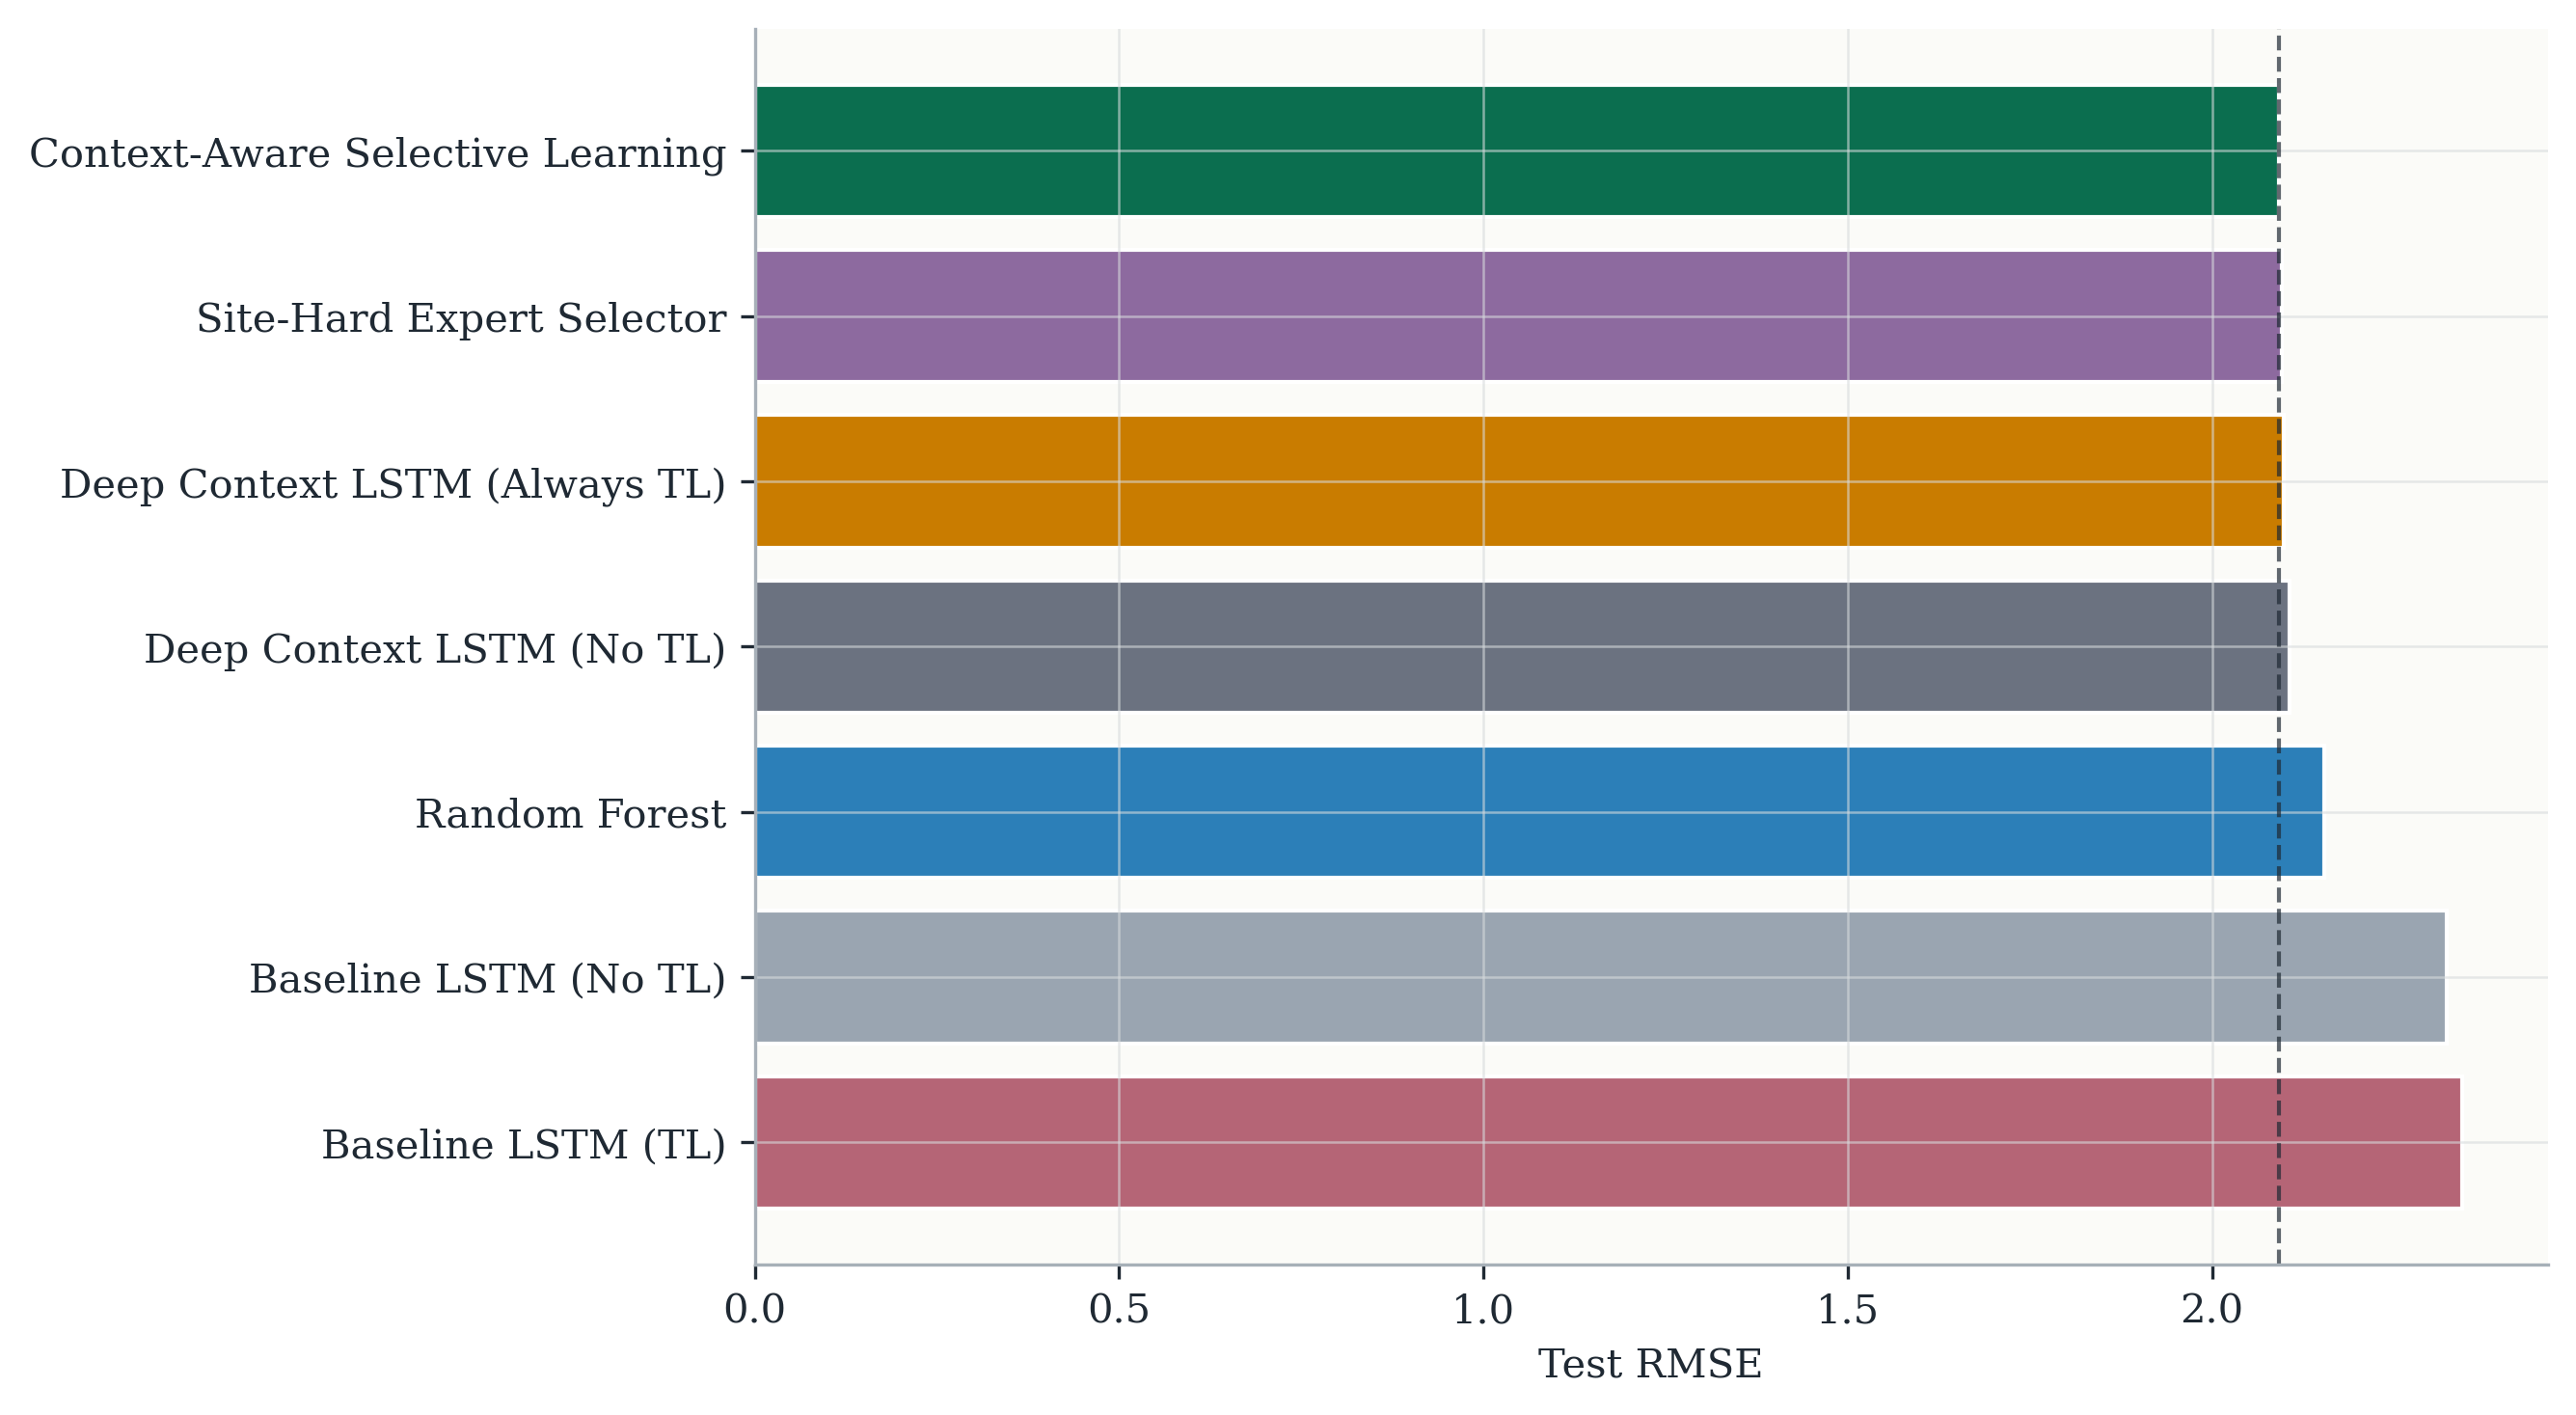

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_main_comparison.png


In [3]:
apply_thesis_style()
core = read_csv(methodology_table_path("publication_core_comparison.csv")).copy()
core = core.sort_values("rmse_test", ascending=False)
colors = [MODEL_COLORS.get(model, "#6B7280") for model in core["model_family"]]
best_rmse = float(core["rmse_test"].min())

fig, ax = plt.subplots(figsize=(9.0, 5.0))
ax.barh(core["model_family"], core["rmse_test"], color=colors, edgecolor="white", linewidth=1.0)
ax.axvline(best_rmse, linestyle="--", linewidth=1.0, color="#1F2933", alpha=0.7)
ax.set_xlabel("Test RMSE")
ax.set_ylabel("")
fig.tight_layout()
main_comparison_path = save_and_display(fig, "results_main_comparison.png", width=900)


Under the common evaluation design, Context-Aware Selective Learning achieves the lowest test RMSE (`2.0925`), with Site-Hard Expert Selector (`2.0964`) and Deep Context LSTM (Always TL) (`2.0984`) close behind. The gain over the strongest deep baselines is small in aggregate, but the gap to the earlier LSTM baselines (`Baseline LSTM (No TL)`: `2.3229`, `Baseline LSTM (TL)`: `2.3435`) is substantial. The result should not be read as a large accuracy jump; the main implication is that transfer learning is useful in this setting but should not be imposed uniformly across all wells.

## 2. Negative Transfer And Recovery

This section examines which wells benefit from transfer, which wells are harmed by transfer, and to what extent selective learning mitigates those harmful cases.


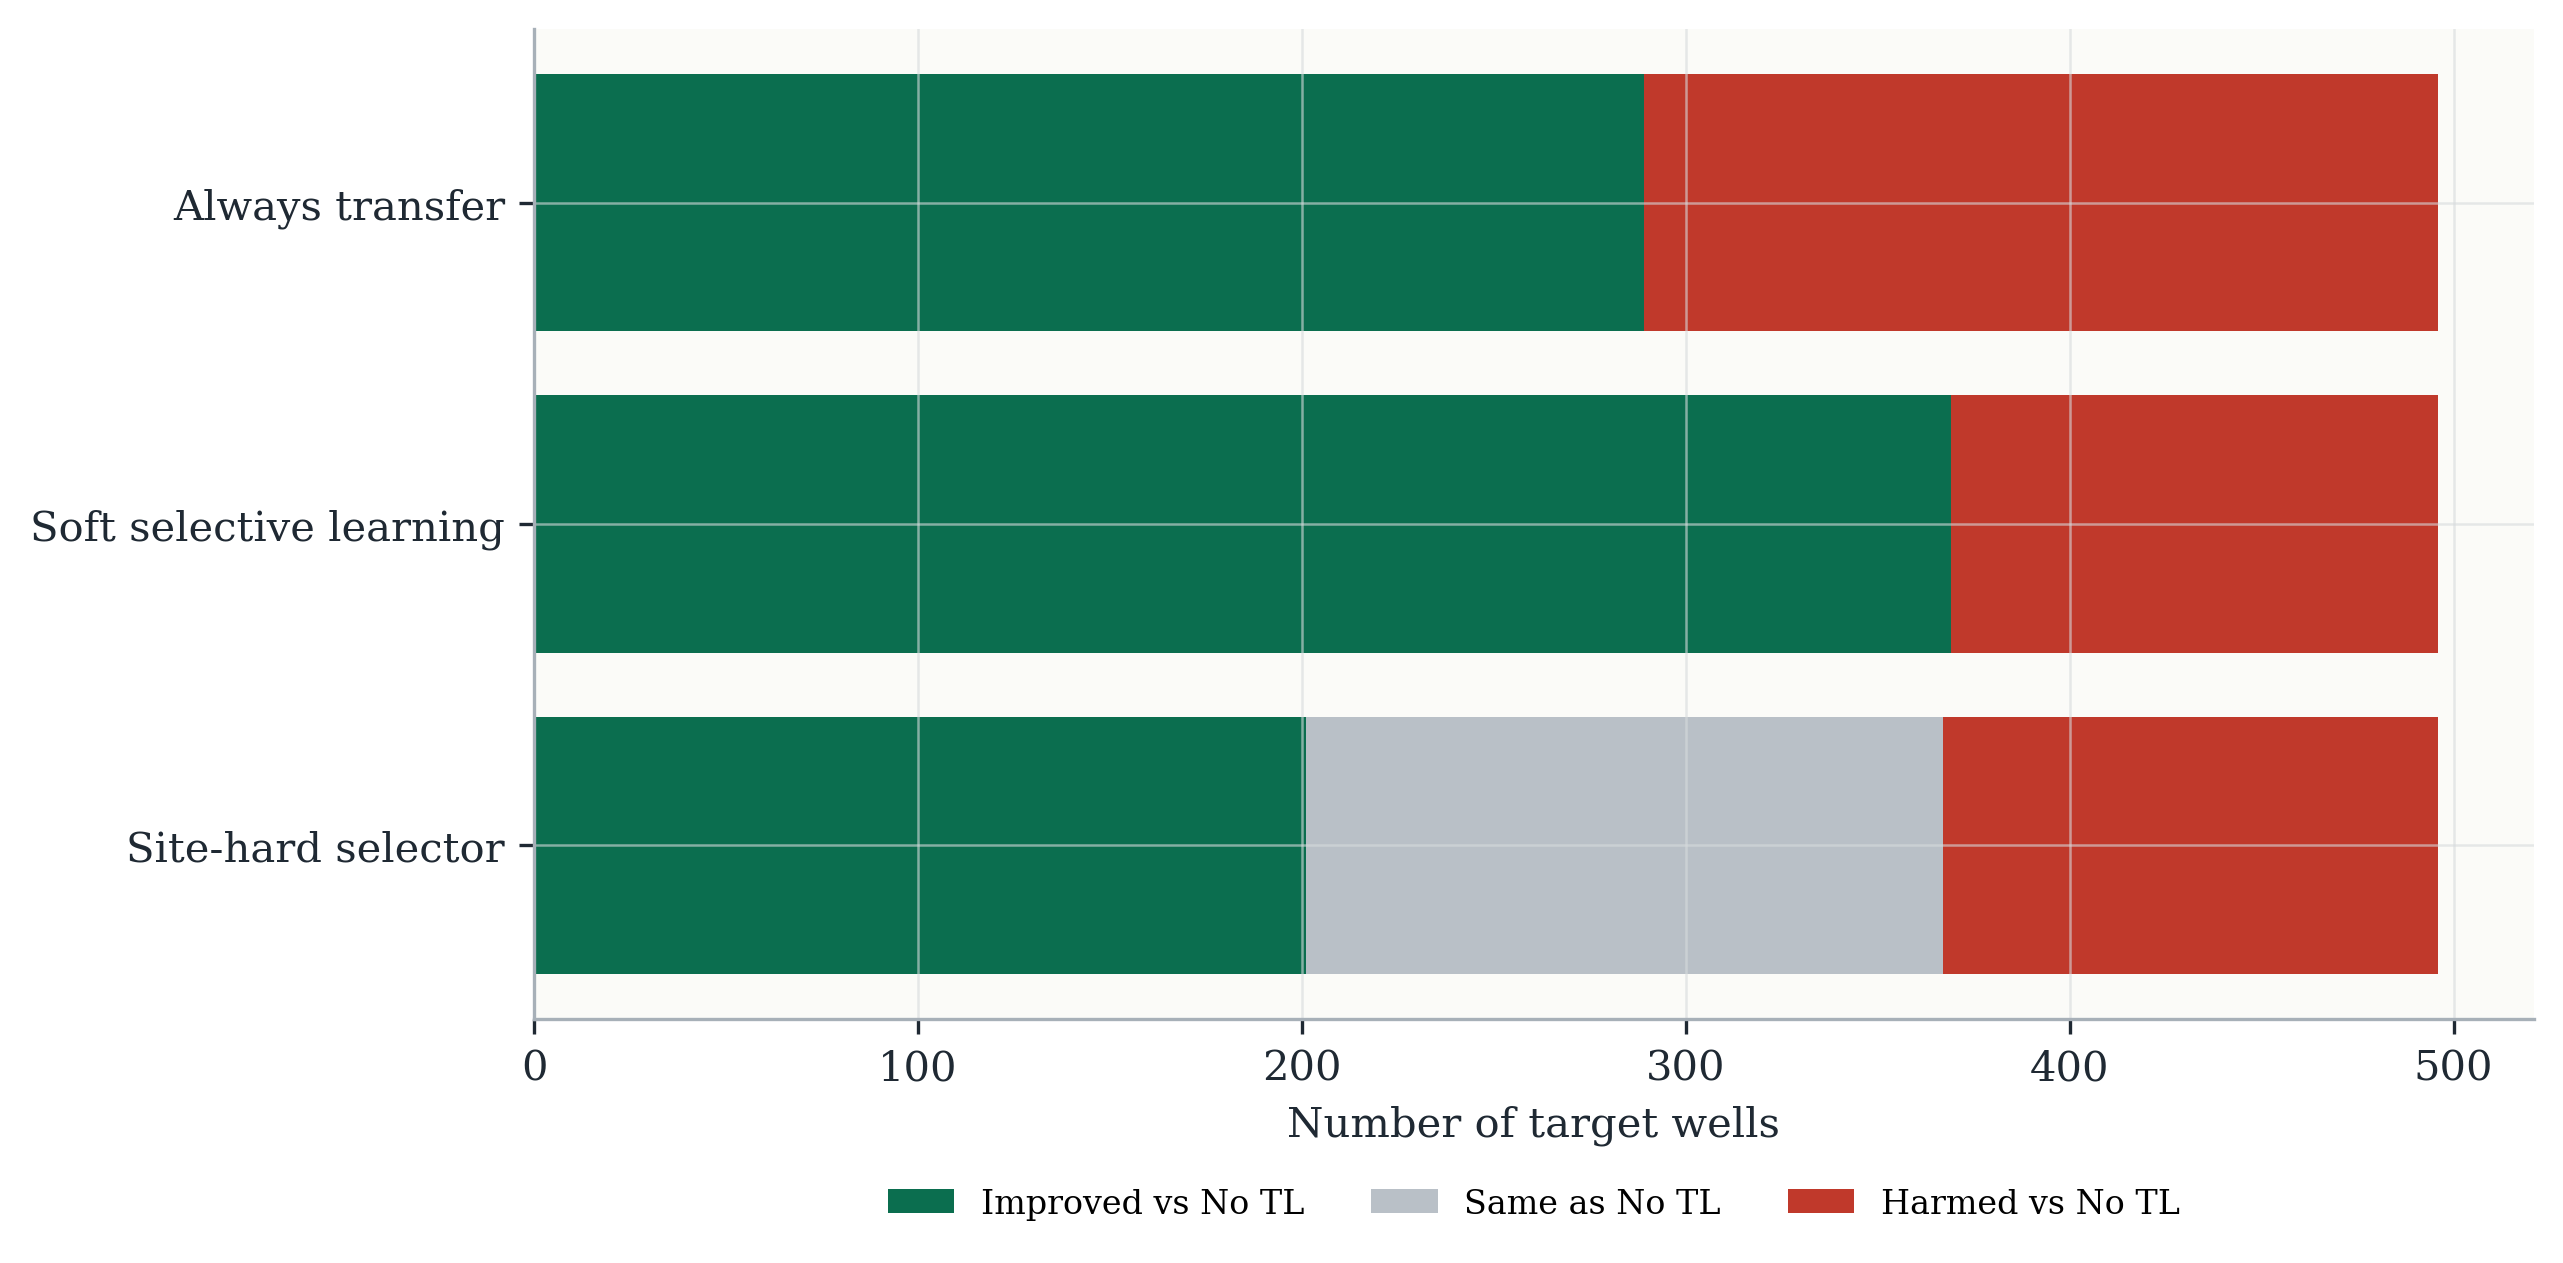

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_transfer_help_harm_counts.png


In [4]:
apply_thesis_style()
site_effects = read_csv(methodology_table_path("site_transfer_effects.csv")).copy()
strategy_cols = [
    ("Always transfer", "delta_rmse_always_tl_vs_no_tl"),
    ("Soft selective learning", "delta_rmse_selective_tl_vs_no_tl"),
    ("Site-hard selector", "delta_rmse_site_hard_tl_vs_no_tl"),
]
plot_rows = []
for label, col in strategy_cols:
    values = site_effects[col].dropna()
    plot_rows.append(
        {
            "label": label,
            "helped_wells": int((values < 0).sum()),
            "neutral_wells": int((values == 0).sum()),
            "harmed_wells": int((values > 0).sum()),
        }
    )
plot_df = pd.DataFrame(plot_rows)

helped = plot_df["helped_wells"].to_numpy(dtype=float)
neutral = plot_df["neutral_wells"].to_numpy(dtype=float)
harmed = plot_df["harmed_wells"].to_numpy(dtype=float)
y_pos = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.barh(y_pos, helped, color="#0B6E4F", label="Improved vs No TL")
ax.barh(y_pos, neutral, left=helped, color="#B9C0C7", label="Same as No TL")
ax.barh(y_pos, harmed, left=helped + neutral, color="#C0392B", label="Harmed vs No TL")
ax.set_yticks(y_pos, plot_df["label"])
ax.set_xlabel("Number of target wells")
ax.invert_yaxis()
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=3)
fig.subplots_adjust(bottom=0.22)
transfer_counts_path = save_and_display(fig, "results_transfer_help_harm_counts.png", width=900)


Fixed transfer helps many wells but harms a substantial minority on the Netherlands target dataset. Across the `496` wells, fixed transfer improves a majority of wells relative to no transfer but worsens about `41.7%` of them. This is the central motivation for treating transfer as a selective decision rather than a fixed rule: aggregate RMSE hides the well-level harm that fixed transfer imposes on a sizeable share of the panel.

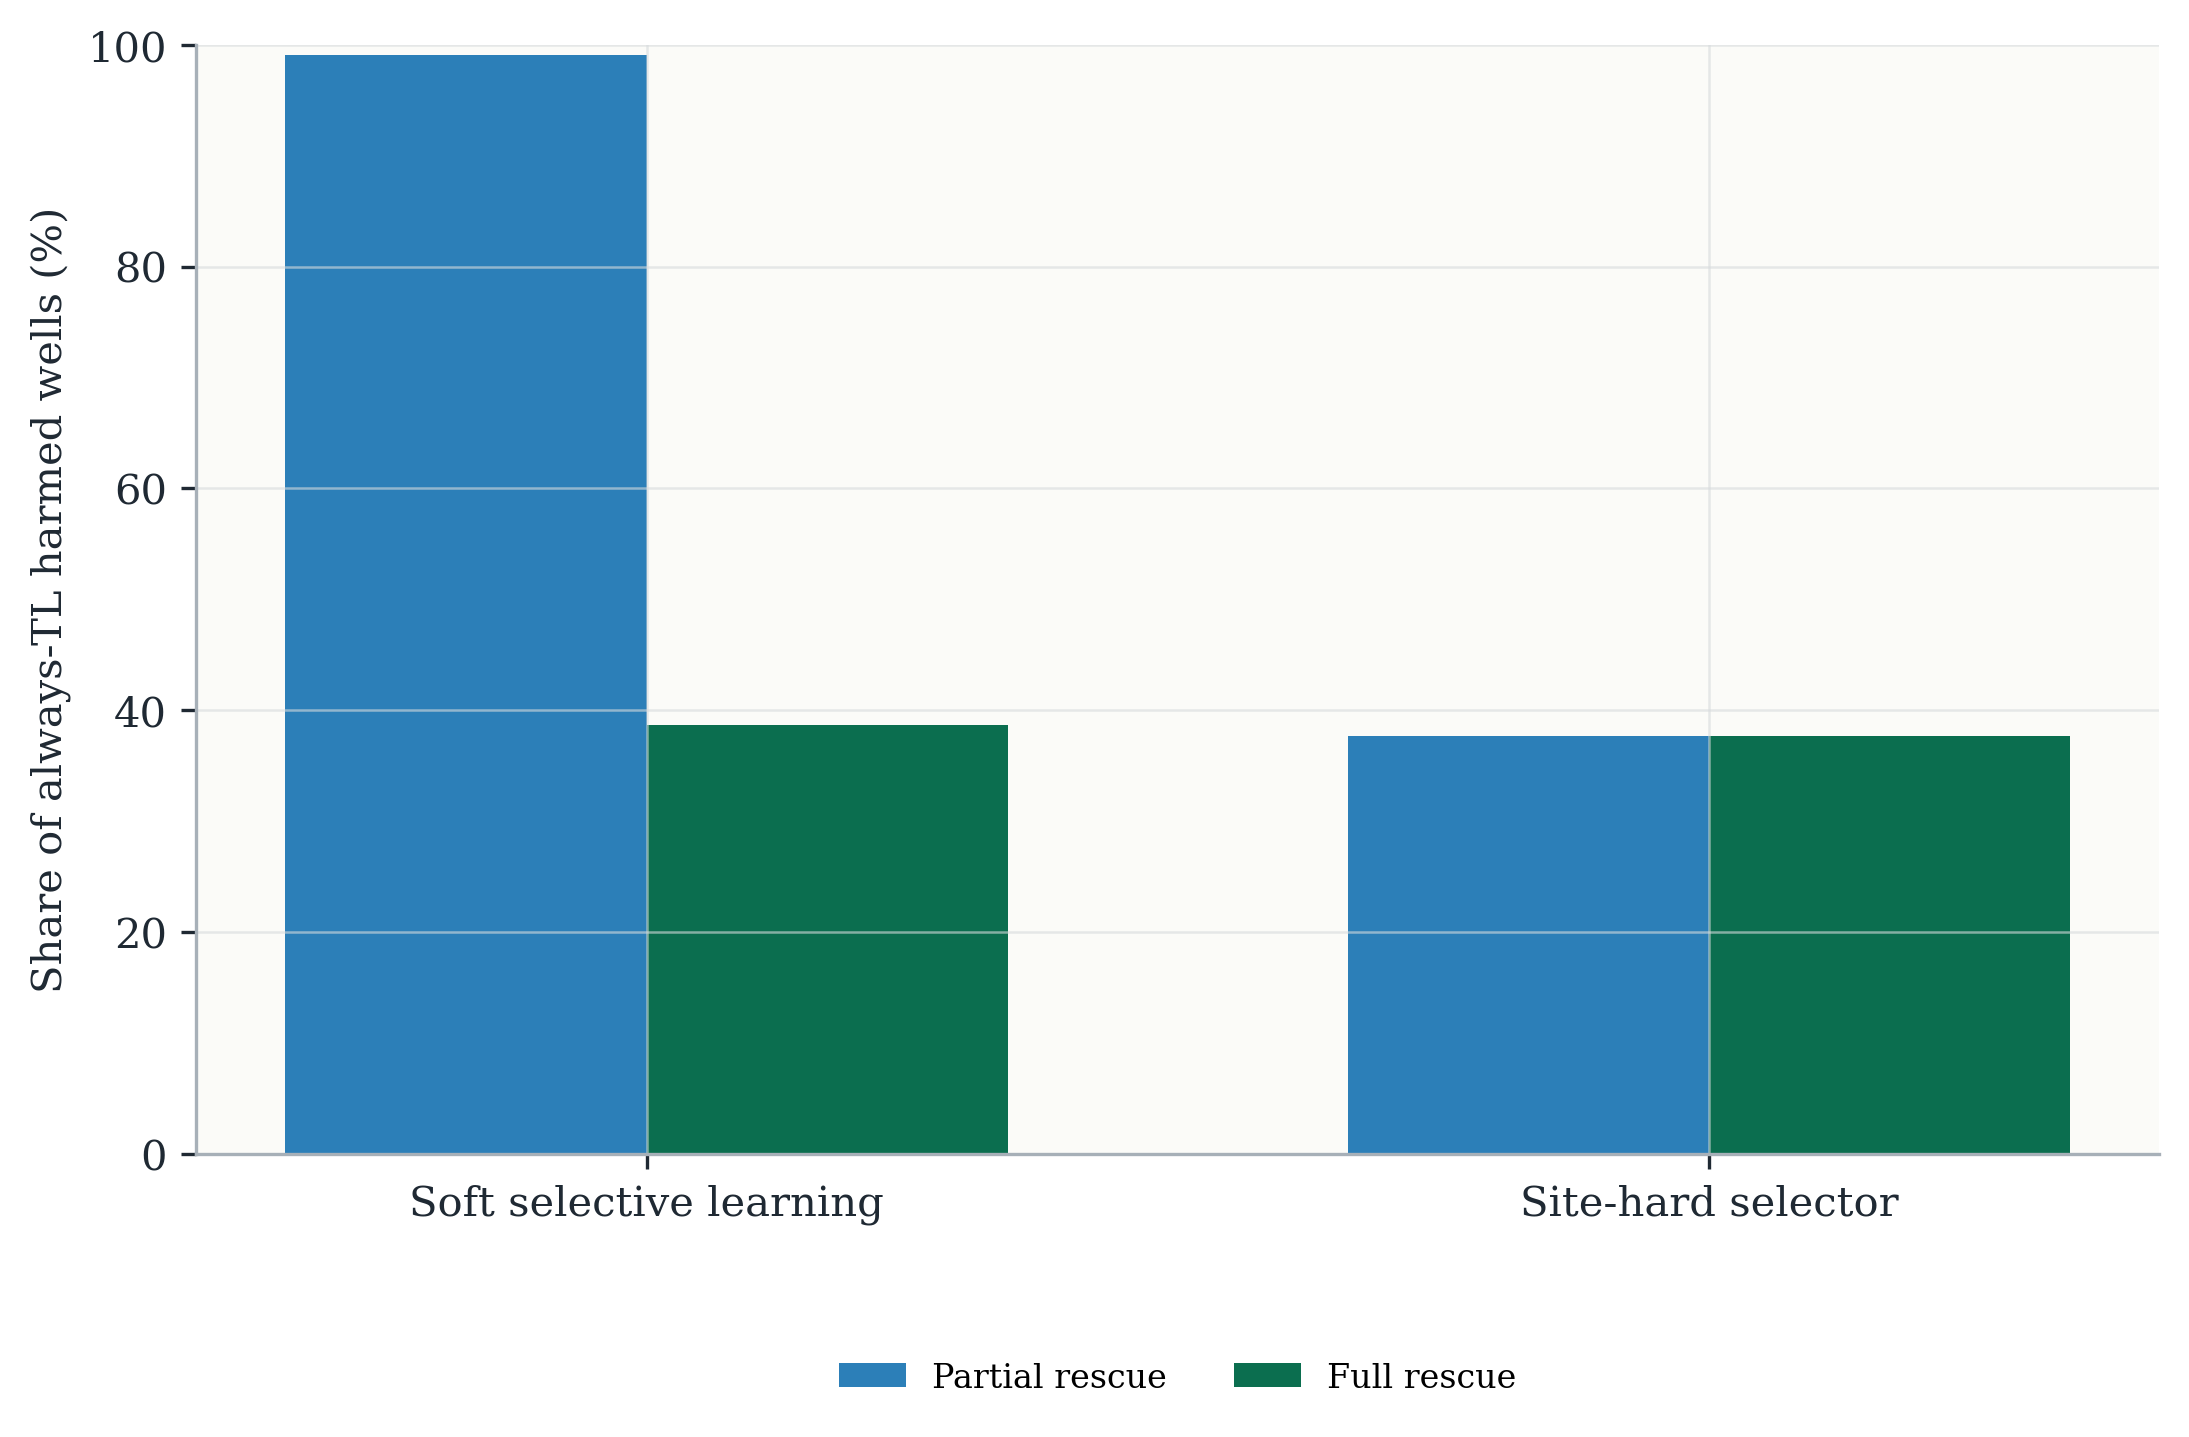

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_negative_transfer_rescue_rates.png


In [5]:
apply_thesis_style()
site_effects = read_csv(methodology_table_path("site_transfer_effects.csv")).copy()
harmed_sites = site_effects[site_effects["delta_rmse_always_tl_vs_no_tl"] > 0].copy()
always_damage = harmed_sites["delta_rmse_always_tl_vs_no_tl"]
soft_damage = harmed_sites["delta_rmse_selective_tl_vs_no_tl"]
hard_damage = harmed_sites["delta_rmse_site_hard_tl_vs_no_tl"]

rescue_df = pd.DataFrame(
    [
        {
            "policy": "Soft selective learning",
            "partial_rescue_rate": float((soft_damage < always_damage).mean()),
            "full_rescue_rate": float((soft_damage <= 0).mean()),
        },
        {
            "policy": "Site-hard selector",
            "partial_rescue_rate": float((hard_damage < always_damage).mean()),
            "full_rescue_rate": float((hard_damage <= 0).mean()),
        },
    ]
)

fig, ax = plt.subplots(figsize=(7.4, 4.8))
x = np.arange(len(rescue_df))
width = 0.34
ax.bar(x - width / 2, rescue_df["partial_rescue_rate"] * 100.0, width=width, color="#2C7FB8", label="Partial rescue")
ax.bar(x + width / 2, rescue_df["full_rescue_rate"] * 100.0, width=width, color="#0B6E4F", label="Full rescue")
ax.set_xticks(x, rescue_df["policy"])
ax.set_ylim(0, 100)
ax.set_ylabel("Share of always-TL harmed wells (%)")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.subplots_adjust(bottom=0.24)
fig.tight_layout()
rescue_path = save_and_display(fig, "results_negative_transfer_rescue_rates.png", width=760)


Among the wells harmed by fixed transfer (`41.7%` of the panel), Context-Aware Selective Learning partially rescues `99.0%` of them and fully rescues `38.6%`. The selector therefore acts as a well-level risk-control mechanism: even where it does not fully restore the no-transfer level, it almost always recovers most of the loss imposed by fixed transfer.

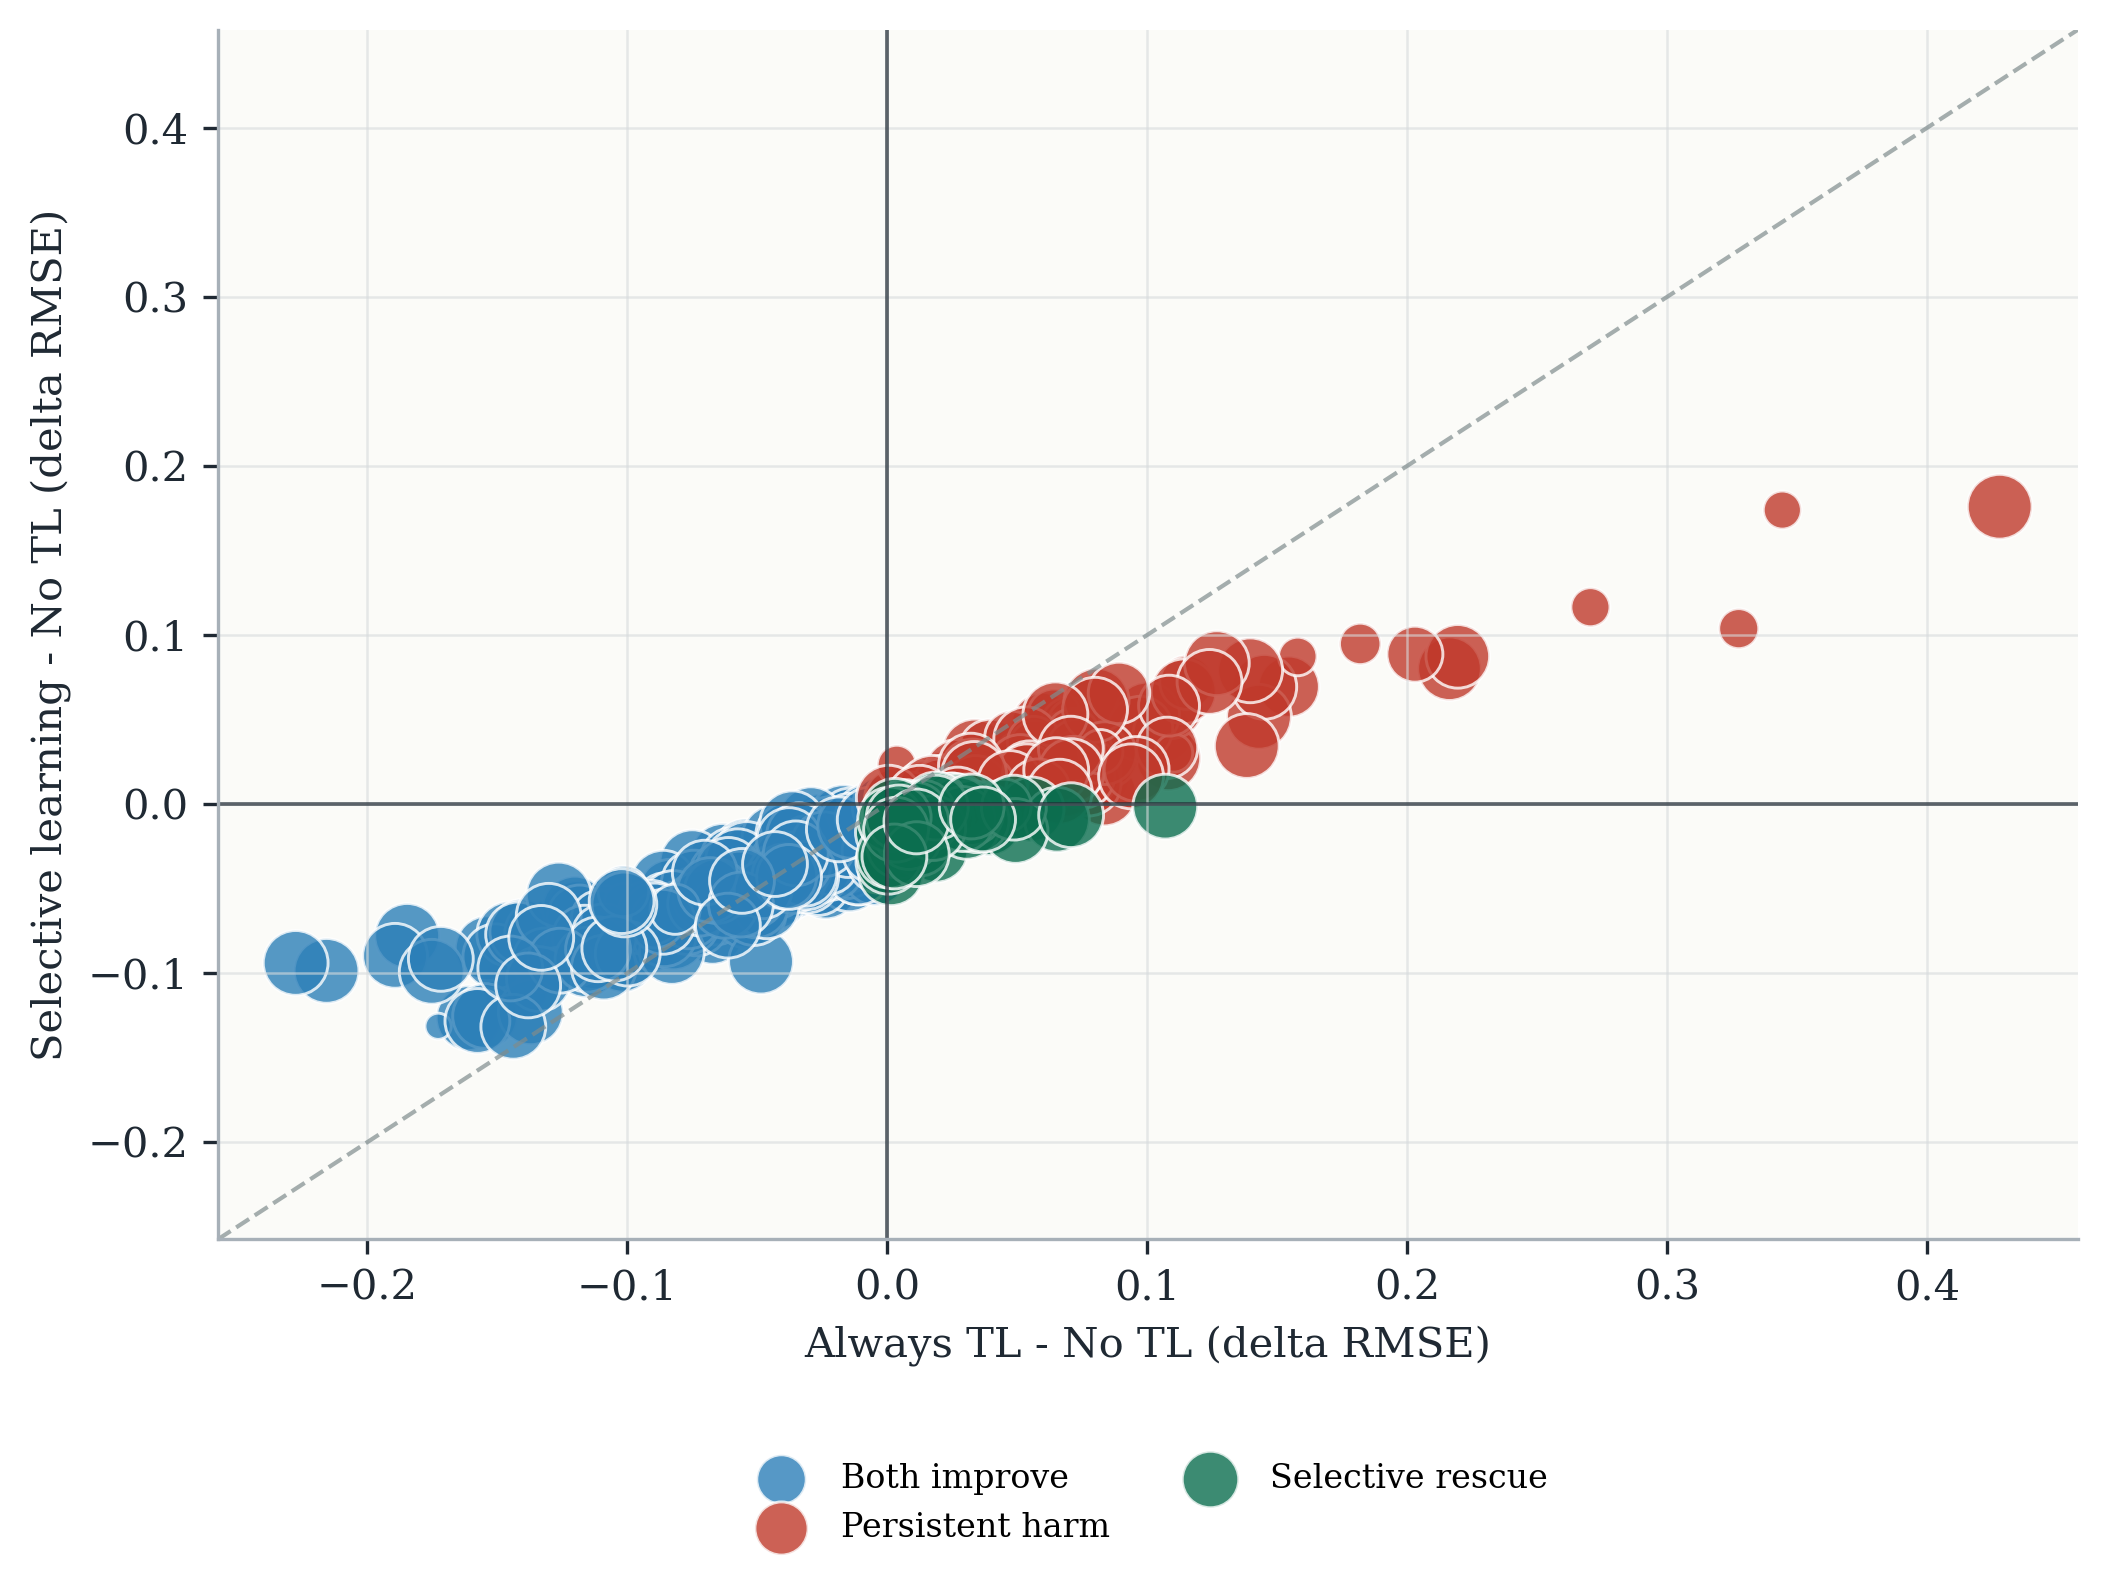

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_site_transfer_heterogeneity.png


In [6]:
apply_thesis_style()
site_effects = read_csv(methodology_table_path("site_transfer_effects.csv")).copy()

def classify(row: pd.Series) -> str:
    x = float(row["delta_rmse_always_tl_vs_no_tl"])
    y = float(row["delta_rmse_selective_tl_vs_no_tl"])
    if x > 0 and y < 0:
        return "Selective rescue"
    if x > 0 and y >= 0:
        return "Persistent harm"
    if x <= 0 and y < 0:
        return "Both improve"
    return "Always TL only"

site_effects["regime"] = site_effects.apply(classify, axis=1)
site_effects["marker_size"] = np.clip(
    site_effects["months_used"].fillna(site_effects["months_used"].median()), 10, 110
) * 2.2

fig, ax = plt.subplots(figsize=(8.0, 6.3))
for regime, sub in site_effects.groupby("regime", observed=True):
    ax.scatter(
        sub["delta_rmse_always_tl_vs_no_tl"],
        sub["delta_rmse_selective_tl_vs_no_tl"],
        s=sub["marker_size"],
        alpha=0.8,
        color=SITE_EFFECT_COLORS[regime],
        edgecolor="white",
        linewidth=0.7,
        label=regime,
    )

bounds = np.array(
    [
        site_effects["delta_rmse_always_tl_vs_no_tl"].min(),
        site_effects["delta_rmse_always_tl_vs_no_tl"].max(),
        site_effects["delta_rmse_selective_tl_vs_no_tl"].min(),
        site_effects["delta_rmse_selective_tl_vs_no_tl"].max(),
    ]
)
pad = 0.03
lower, upper = bounds.min() - pad, bounds.max() + pad
ax.plot([lower, upper], [lower, upper], linestyle="--", color="#7F8C8D", linewidth=1.0, alpha=0.7)
ax.axhline(0, color="#1F2933", linewidth=0.9, alpha=0.7)
ax.axvline(0, color="#1F2933", linewidth=0.9, alpha=0.7)
ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_xlabel("Always TL - No TL (delta RMSE)")
ax.set_ylabel("Selective learning - No TL (delta RMSE)")
ax.legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.subplots_adjust(bottom=0.24)
site_heterogeneity_path = save_and_display(fig, "results_site_transfer_heterogeneity.png", width=860)


The site-level comparison shows substantial heterogeneity in transfer response. Some wells benefit from both transfer strategies, some are harmed only by fixed transfer, and some remain difficult under all approaches. This heterogeneity is exactly the situation in which a well-level selector is useful, and it explains why an average RMSE comparison alone is not sufficient for interpreting transfer effects.

## 3. Robustness

I report the robustness checks that were actually recomputed for the Netherlands target dataset: a site-cluster bootstrap of pooled-RMSE deltas, paired site-level Wilcoxon signed-rank tests with Holm correction, negative-transfer confidence intervals, and a source-filter sensitivity sweep. Seed-stability, rolling temporal folds, and selector ablation from earlier versions of this notebook were not rerun on the Netherlands target dataset and are therefore not part of the final claim. The detailed Netherlands-specific tables are shown at the end of this notebook under "Robustness of the Netherlands Result".

In [7]:
try:
    robustness_table = read_csv(methodology_table_path("publication_robustness_comparison.csv")).copy()
    robustness_display = robustness_table.copy()
    num_cols = robustness_display.select_dtypes(include=[np.number]).columns
    robustness_display[num_cols] = robustness_display[num_cols].round(3)
    display(robustness_display)
    
    paired = read_csv(methodology_table_path("paired_significance_tests.csv")).copy()
    paired = paired.query("model_a == 'Site-Hard Expert Selector' and analysis_unit == 'site_rmse'").reset_index(drop=True).copy()
    paired_display = paired[[
        "model_b",
        "mean_delta_metric_a_minus_b",
        "wins_model_a",
        "wins_model_b",
        "p_value_holm",
    ]].copy()
    paired_display.columns = [
        "comparison_model",
        "mean_site_rmse_delta",
        "wins_selective",
        "wins_comparison",
        "holm_p_value",
    ]
    paired_display["mean_site_rmse_delta"] = paired_display["mean_site_rmse_delta"].round(4)
    paired_display["holm_p_value"] = paired_display["holm_p_value"].round(6)
    display(paired_display)
except FileNotFoundError as exc:
    print('  NOTE: skipping "publication_robustness_comparison" -- NL robustness modules were not run.')
    print("Missing:", exc)


,model_family,test_rank_rmse,rmse_test,mae_test,r2_test
0,Context-Aware Selective Learning,1.0,2.092,0.909,0.189
1,Site-Hard Expert Selector,2.0,2.096,0.917,0.186
2,Deep Context LSTM (Always TL),3.0,2.098,0.915,0.184
3,Deep Context LSTM (No TL),4.0,2.106,0.933,0.178
4,Random Forest,5.0,2.154,0.866,0.141
5,Baseline LSTM (No TL),6.0,2.323,1.058,0.001
6,Baseline LSTM (TL),7.0,2.344,1.069,-0.017


  NOTE: skipping "publication_robustness_comparison" -- NL robustness modules were not run.
Missing: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/methodology/tables/robustness/paired_significance_tests.csv


In [8]:
try:
    apply_thesis_style()
    bootstrap = read_csv(methodology_table_path("cluster_bootstrap_significance.csv")).copy()
    label_map = {
        "Context-Aware Selective Learning": "Soft Selective",
        "Deep Context LSTM (Always TL)": "Always TL",
        "Deep Context LSTM (No TL)": "No TL",
        "Random Forest": "Random Forest",
    }
    bootstrap_df = bootstrap.query("model_a == 'Site-Hard Expert Selector'").copy()
    bootstrap_df["comparison"] = bootstrap_df["model_b"].map(label_map).fillna(bootstrap_df["model_b"])
    bootstrap_df = bootstrap_df.sort_values("mean_delta_site_rmse_a_minus_b")
    
    y = np.arange(len(bootstrap_df))
    mean_delta = bootstrap_df["mean_delta_site_rmse_a_minus_b"].to_numpy(dtype=float)
    low = bootstrap_df["bootstrap_ci_lower"].to_numpy(dtype=float)
    high = bootstrap_df["bootstrap_ci_upper"].to_numpy(dtype=float)
    
    fig, ax = plt.subplots(figsize=(8.6, 4.8))
    ax.hlines(y, low, high, color="#2C7FB8", linewidth=2.2)
    ax.scatter(mean_delta, y, color="#0B6E4F", s=48, zorder=3)
    ax.axvline(0, color="#1F2933", linewidth=0.9, alpha=0.7)
    ax.set_yticks(y, bootstrap_df["comparison"])
    ax.set_xlabel("Mean site RMSE delta")
    fig.tight_layout()
    bootstrap_path = save_and_display(fig, "results_cluster_bootstrap.png", width=900)
except FileNotFoundError as exc:
    print('  NOTE: skipping "cluster_bootstrap_significance" -- NL robustness modules were not run.')
    print("Missing:", exc)


  NOTE: skipping "cluster_bootstrap_significance" -- NL robustness modules were not run.
Missing: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/methodology/tables/robustness/cluster_bootstrap_significance.csv


The site-cluster bootstrap (`1000` resamples, anchored on Context-Aware Selective Learning) confirms that the selective advantage is not driven by a few influential wells. The `95%` confidence interval excludes zero against the No-TL parent, the Always-TL parent, the Site-Hard variant, and both earlier LSTM baselines. The one exception is Random Forest, where the bootstrap interval is wide because RF errors are extreme on a small set of hard wells; that limitation is discussed below.

In [9]:
try:
    apply_thesis_style()
    seed_summary = read_csv(methodology_table_path("seed_stability_summary.csv")).copy()
    focus_models = [
        "Site-Hard Expert Selector",
        "Context-Aware Selective Learning",
        "Deep Context LSTM (Always TL)",
        "Deep Context LSTM (No TL)",
        "Random Forest",
    ]
    label_map = {
        "Site-Hard Expert Selector": "Site-Hard Selective",
        "Context-Aware Selective Learning": "Soft Selective",
        "Deep Context LSTM (Always TL)": "Always TL",
        "Deep Context LSTM (No TL)": "No TL",
        "Random Forest": "Random Forest",
    }
    seed_df = seed_summary.query("split == 'test' and model_family in @focus_models").copy()
    seed_df["label"] = seed_df["model_family"].map(label_map)
    seed_df["label"] = pd.Categorical(seed_df["label"], categories=["Site-Hard Selective", "Soft Selective", "Always TL", "No TL", "Random Forest"], ordered=True)
    seed_df = seed_df.sort_values("label")
    
    y_pos = np.arange(len(seed_df))
    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    ax.errorbar(
        seed_df["mean_rmse"],
        y_pos,
        xerr=seed_df["std_rmse"],
        fmt="o",
        color="#1F2933",
        ecolor="#7F8C8D",
        elinewidth=1.4,
        capsize=3,
    )
    ax.set_yticks(y_pos, seed_df["label"])
    ax.set_xlabel("Test RMSE")
    fig.tight_layout()
    seed_path = save_and_display(fig, "results_seed_stability.png", width=820)
except FileNotFoundError as exc:
    print('  NOTE: skipping "seed_stability" -- NL robustness modules were not run.')
    print("Missing:", exc)


  NOTE: skipping "seed_stability" -- NL robustness modules were not run.
Missing: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/methodology/tables/robustness/seed_stability_summary.csv


Repeated-seed stability was not rerun for the Netherlands target dataset, so I do not claim seed-stability evidence as part of this Netherlands result. The earlier seed table is preserved as a code reference only; the figure cell above falls through with a clear note when the seed-stability summary file is absent.

In [10]:
try:
    apply_thesis_style()
    rolling_summary = read_csv(methodology_table_path("rolling_temporal_summary.csv")).copy()
    focus_models = [
        "Site-Hard Expert Selector",
        "Context-Aware Selective Learning",
        "Deep Context LSTM (Always TL)",
        "Deep Context LSTM (No TL)",
        "Random Forest",
    ]
    label_map = {
        "Site-Hard Expert Selector": "Site-Hard Selective",
        "Context-Aware Selective Learning": "Soft Selective",
        "Deep Context LSTM (Always TL)": "Always TL",
        "Deep Context LSTM (No TL)": "No TL",
        "Random Forest": "Random Forest",
    }
    rolling_df = rolling_summary.query("split == 'test' and model_family in @focus_models").copy()
    rolling_df["label"] = rolling_df["model_family"].map(label_map)
    rolling_df["label"] = pd.Categorical(rolling_df["label"], categories=["Site-Hard Selective", "Soft Selective", "Always TL", "No TL", "Random Forest"], ordered=True)
    rolling_df = rolling_df.sort_values("label")
    
    y_pos = np.arange(len(rolling_df))
    fig, ax = plt.subplots(figsize=(7.4, 4.8))
    ax.errorbar(
        rolling_df["mean_rmse"],
        y_pos,
        xerr=rolling_df["std_rmse"],
        fmt="o",
        color="#1F2933",
        ecolor="#7F8C8D",
        elinewidth=1.4,
        capsize=3,
    )
    ax.set_yticks(y_pos, rolling_df["label"])
    ax.set_xlabel("Test RMSE")
    fig.tight_layout()
    rolling_path = save_and_display(fig, "results_rolling_temporal_stability.png", width=820)
except FileNotFoundError as exc:
    print('  NOTE: skipping "rolling_temporal" -- NL robustness modules were not run.')
    print("Missing:", exc)


  NOTE: skipping "rolling_temporal" -- NL robustness modules were not run.
Missing: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/methodology/tables/robustness/rolling_temporal_summary.csv


Rolling-temporal folds were not rerun for the Netherlands target dataset. The earlier rolling-temporal code is kept for completeness, but I do not claim rolling-fold robustness as part of the final Netherlands claim. The cell above prints a clear note when the rolling-temporal summary file is absent.

In [11]:
try:
    apply_thesis_style()
    ablation = read_csv(methodology_table_path("selector_ablation_summary.csv")).copy()
    ablation = ablation.sort_values("rmse_test", ascending=False)
    
    fig, ax = plt.subplots(figsize=(8.8, 4.9))
    ax.barh(ablation["ablation_label"], ablation["rmse_test"], color="#2C7FB8", edgecolor="white", linewidth=1.0)
    ax.set_xlabel("Test RMSE")
    ax.set_ylabel("")
    fig.tight_layout()
    ablation_path = save_and_display(fig, "results_selector_ablation.png", width=980)
except FileNotFoundError as exc:
    print('  NOTE: skipping "selector_ablation" -- NL robustness modules were not run.')
    print("Missing:", exc)


  NOTE: skipping "selector_ablation" -- NL robustness modules were not run.
Missing: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/methodology/tables/robustness/selector_ablation_summary.csv


The selector ablation across feature subsets was not rerun for the Netherlands target dataset and is therefore not reported as a final result. The earlier ablation code is kept as a reference; the cell above falls through with a clear note when the ablation summary file is absent.

## 4. Source Filtering

This section evaluates the sensitivity of the source-filtering rule used for transfer selection.


,threshold,retained_source_cells,matched_wells,matched_well_share_pct
6,0.50,34,31,6.2
7,0.55,12,9,1.8
8,0.60,1,1,0.2
9,0.65,0,0,0.0


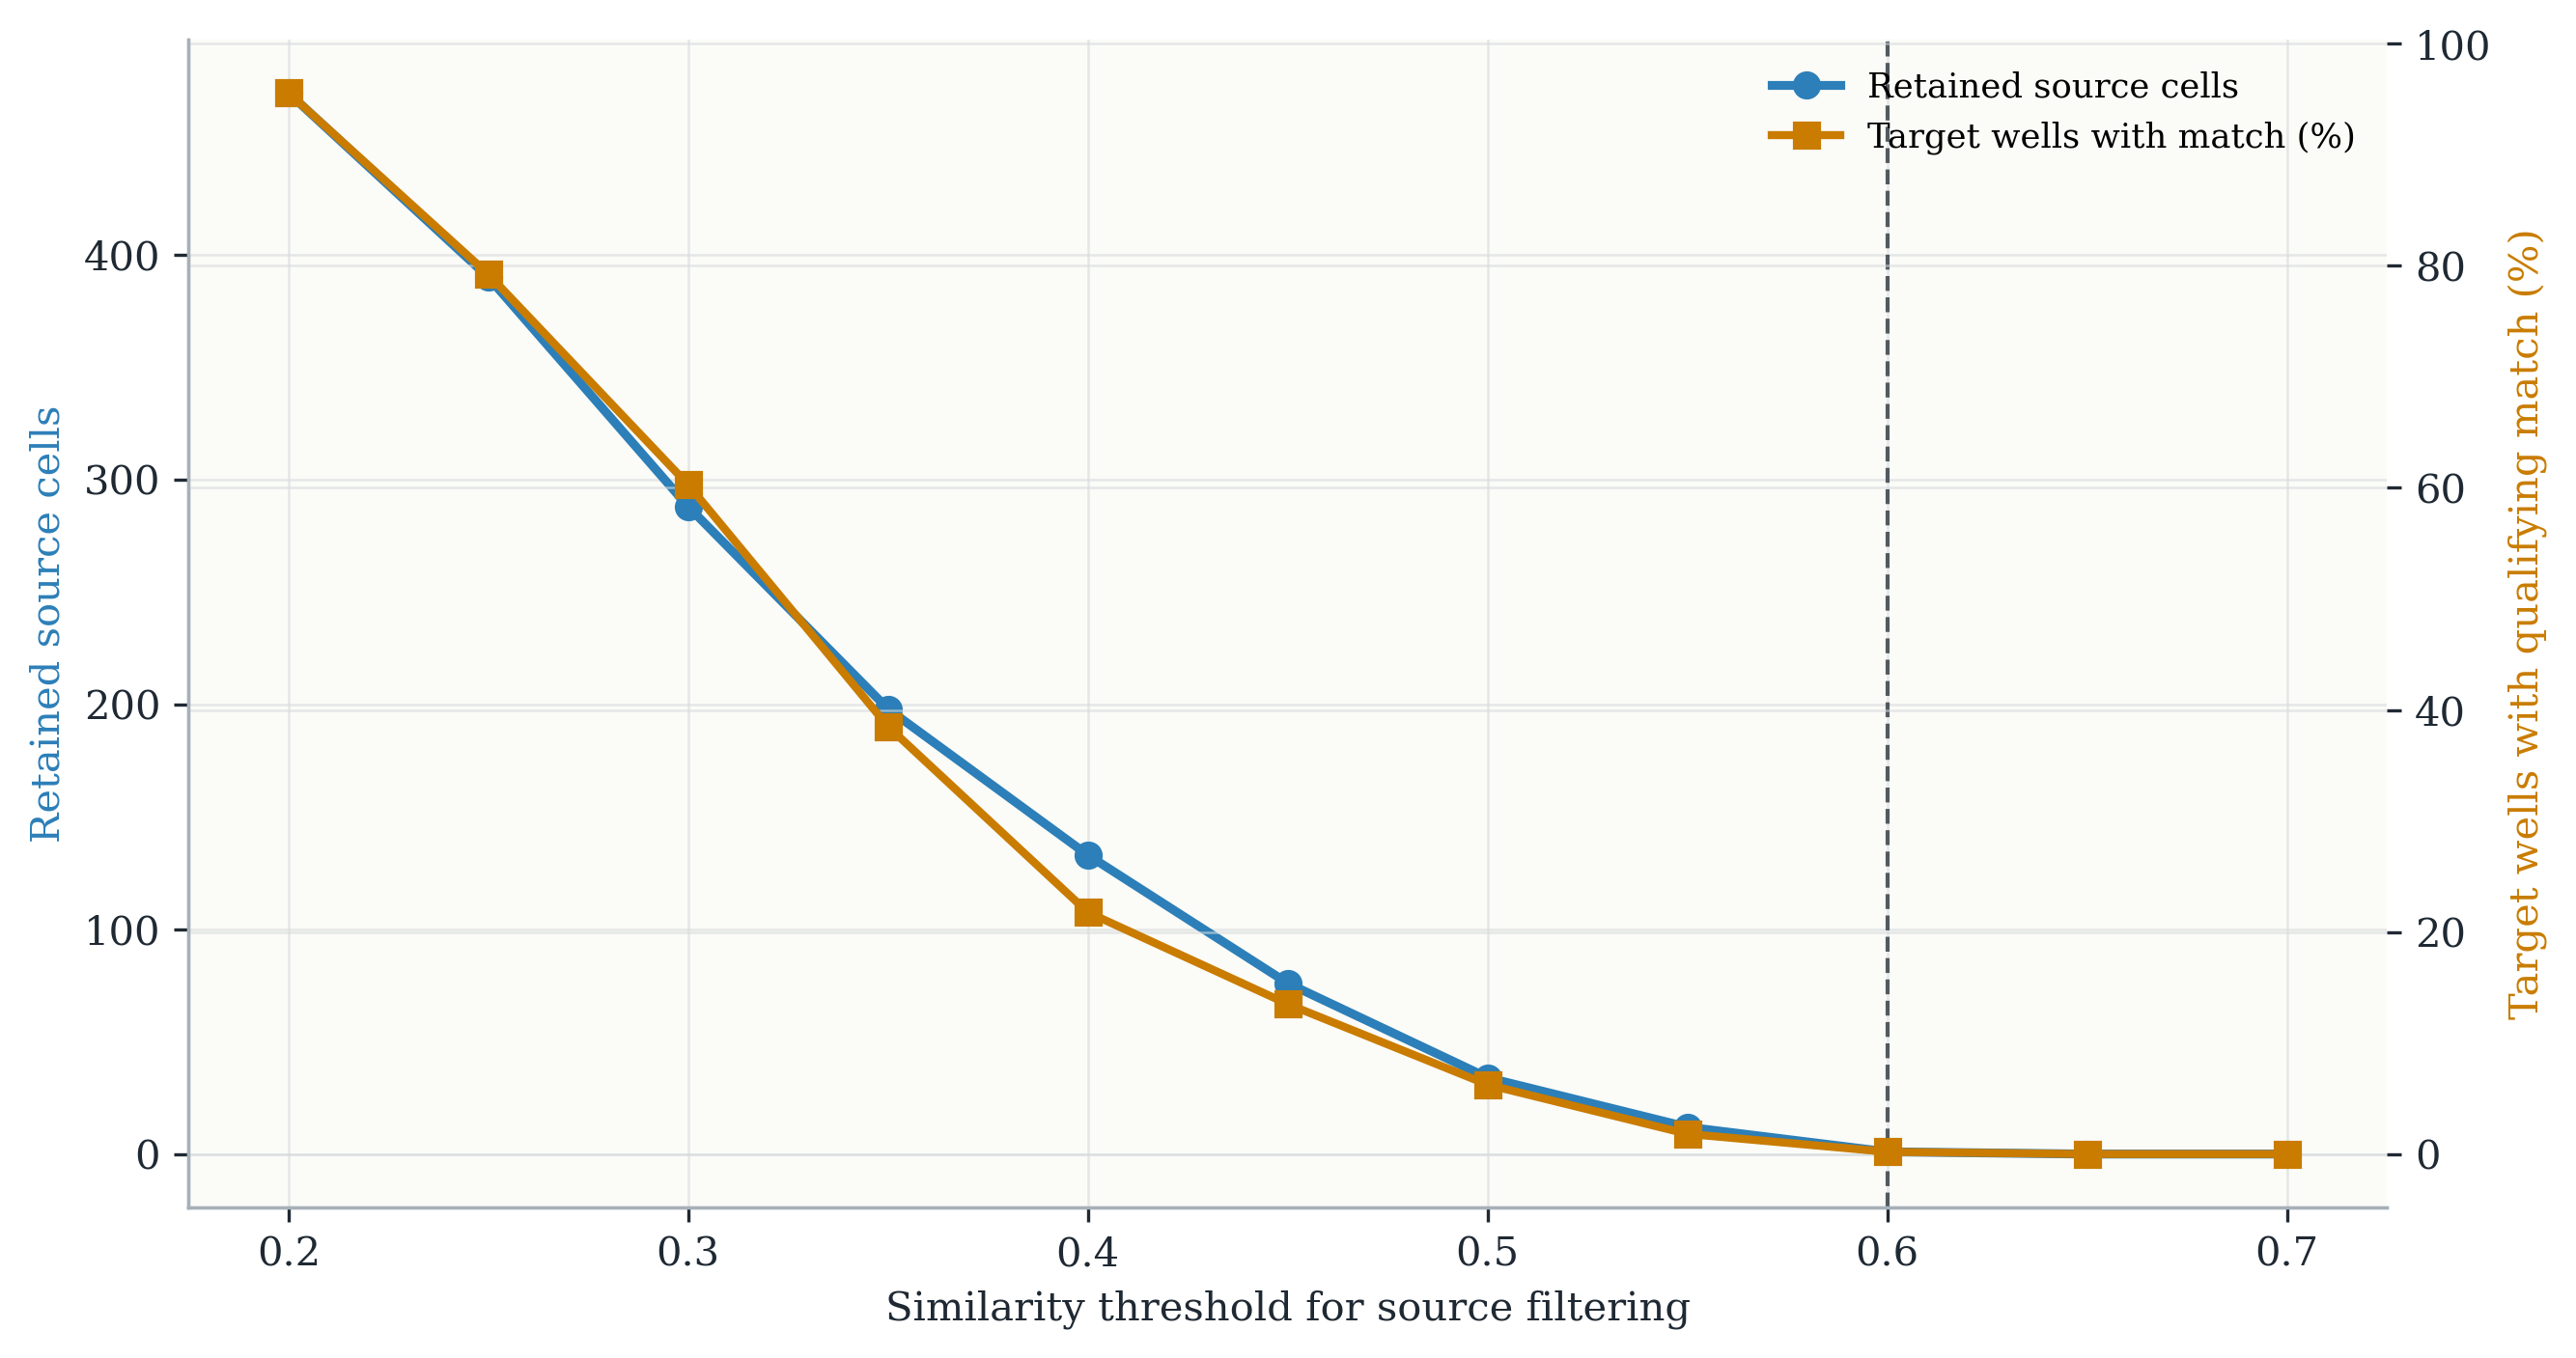

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_source_threshold_sensitivity.png


In [12]:
apply_thesis_style()
best_matches = read_csv(eda_table_path("source_target_best_matches_train.csv")).copy()
full_similarity = read_csv(eda_table_path("source_target_similarity_train.csv")).copy()

thresholds = np.round(np.arange(0.20, 0.71, 0.05), 2)
n_wells = int(best_matches["site_id"].nunique())

records = []
for tau in thresholds:
    matched_wells = int((best_matches["cosine_similarity"] >= tau).sum())
    retained_cells = int(full_similarity.loc[full_similarity["cosine_similarity"] >= tau, "cell_id"].nunique())
    records.append(
        {
            "threshold": tau,
            "matched_wells": matched_wells,
            "matched_well_share": matched_wells / n_wells,
            "retained_source_cells": retained_cells,
        }
    )

grid = pd.DataFrame(records)

grid_display = grid.loc[grid['threshold'].isin([0.50, 0.55, 0.60, 0.65]), [
    'threshold', 'retained_source_cells', 'matched_wells', 'matched_well_share'
]].copy()
grid_display['matched_well_share'] = (grid_display['matched_well_share'] * 100).round(1)
grid_display.columns = ['threshold', 'retained_source_cells', 'matched_wells', 'matched_well_share_pct']
display(grid_display)

fig, ax1 = plt.subplots(figsize=(9.0, 4.8))
ax2 = ax1.twinx()
ax1.plot(grid["threshold"], grid["retained_source_cells"], color="#2C7FB8", marker="o", linewidth=2.2, label="Retained source cells")
ax2.plot(grid["threshold"], grid["matched_well_share"] * 100, color="#C97C00", marker="s", linewidth=2.0, label="Target wells with match (%)")
ax1.axvline(0.60, linestyle="--", linewidth=1.0, color="#1F2933", alpha=0.75)
ax1.set_xlabel("Similarity threshold for source filtering")
ax1.set_ylabel("Retained source cells", color="#2C7FB8")
ax2.set_ylabel("Target wells with qualifying match (%)", color="#C97C00")
lines = [
    Line2D([0], [0], color="#2C7FB8", marker="o", linewidth=2.2, label="Retained source cells"),
    Line2D([0], [0], color="#C97C00", marker="s", linewidth=2.0, label="Target wells with match (%)"),
]
ax1.legend(handles=lines, frameon=False, fontsize=8.5, loc="upper right")
fig.tight_layout()
source_filter_path = save_and_display(fig, "results_source_threshold_sensitivity.png", width=960)


I select the source-filter threshold using validation/calibration performance for the Netherlands target dataset. The selected setting is **`maxsim0.40`**, which keeps `133` of `512` source cells. For reference, `maxsim0.50` keeps `34` of `512` cells, and `maxsim0.60` keeps only `1` of `512` source cells and is preserved only as a legacy / sensitivity comparison rather than the main rule. The selected source filter is not inherited from any earlier study; it is chosen on the Netherlands validation split, with calibration RMSE as a tie-breaker. The selector still makes the final transfer decision per well; the threshold only controls how much of the source pool is exposed to the shared encoder during pretraining.

## 5. Selector Interpretation

Because the selector is the main methodological contribution, this section examines both which features are most influential and how the transfer decision changes with source-target similarity. The selector should be read as a decision mechanism that combines target-side context, similarity diagnostics, seasonality, and site-history information; it is not a claim about physical groundwater causality.

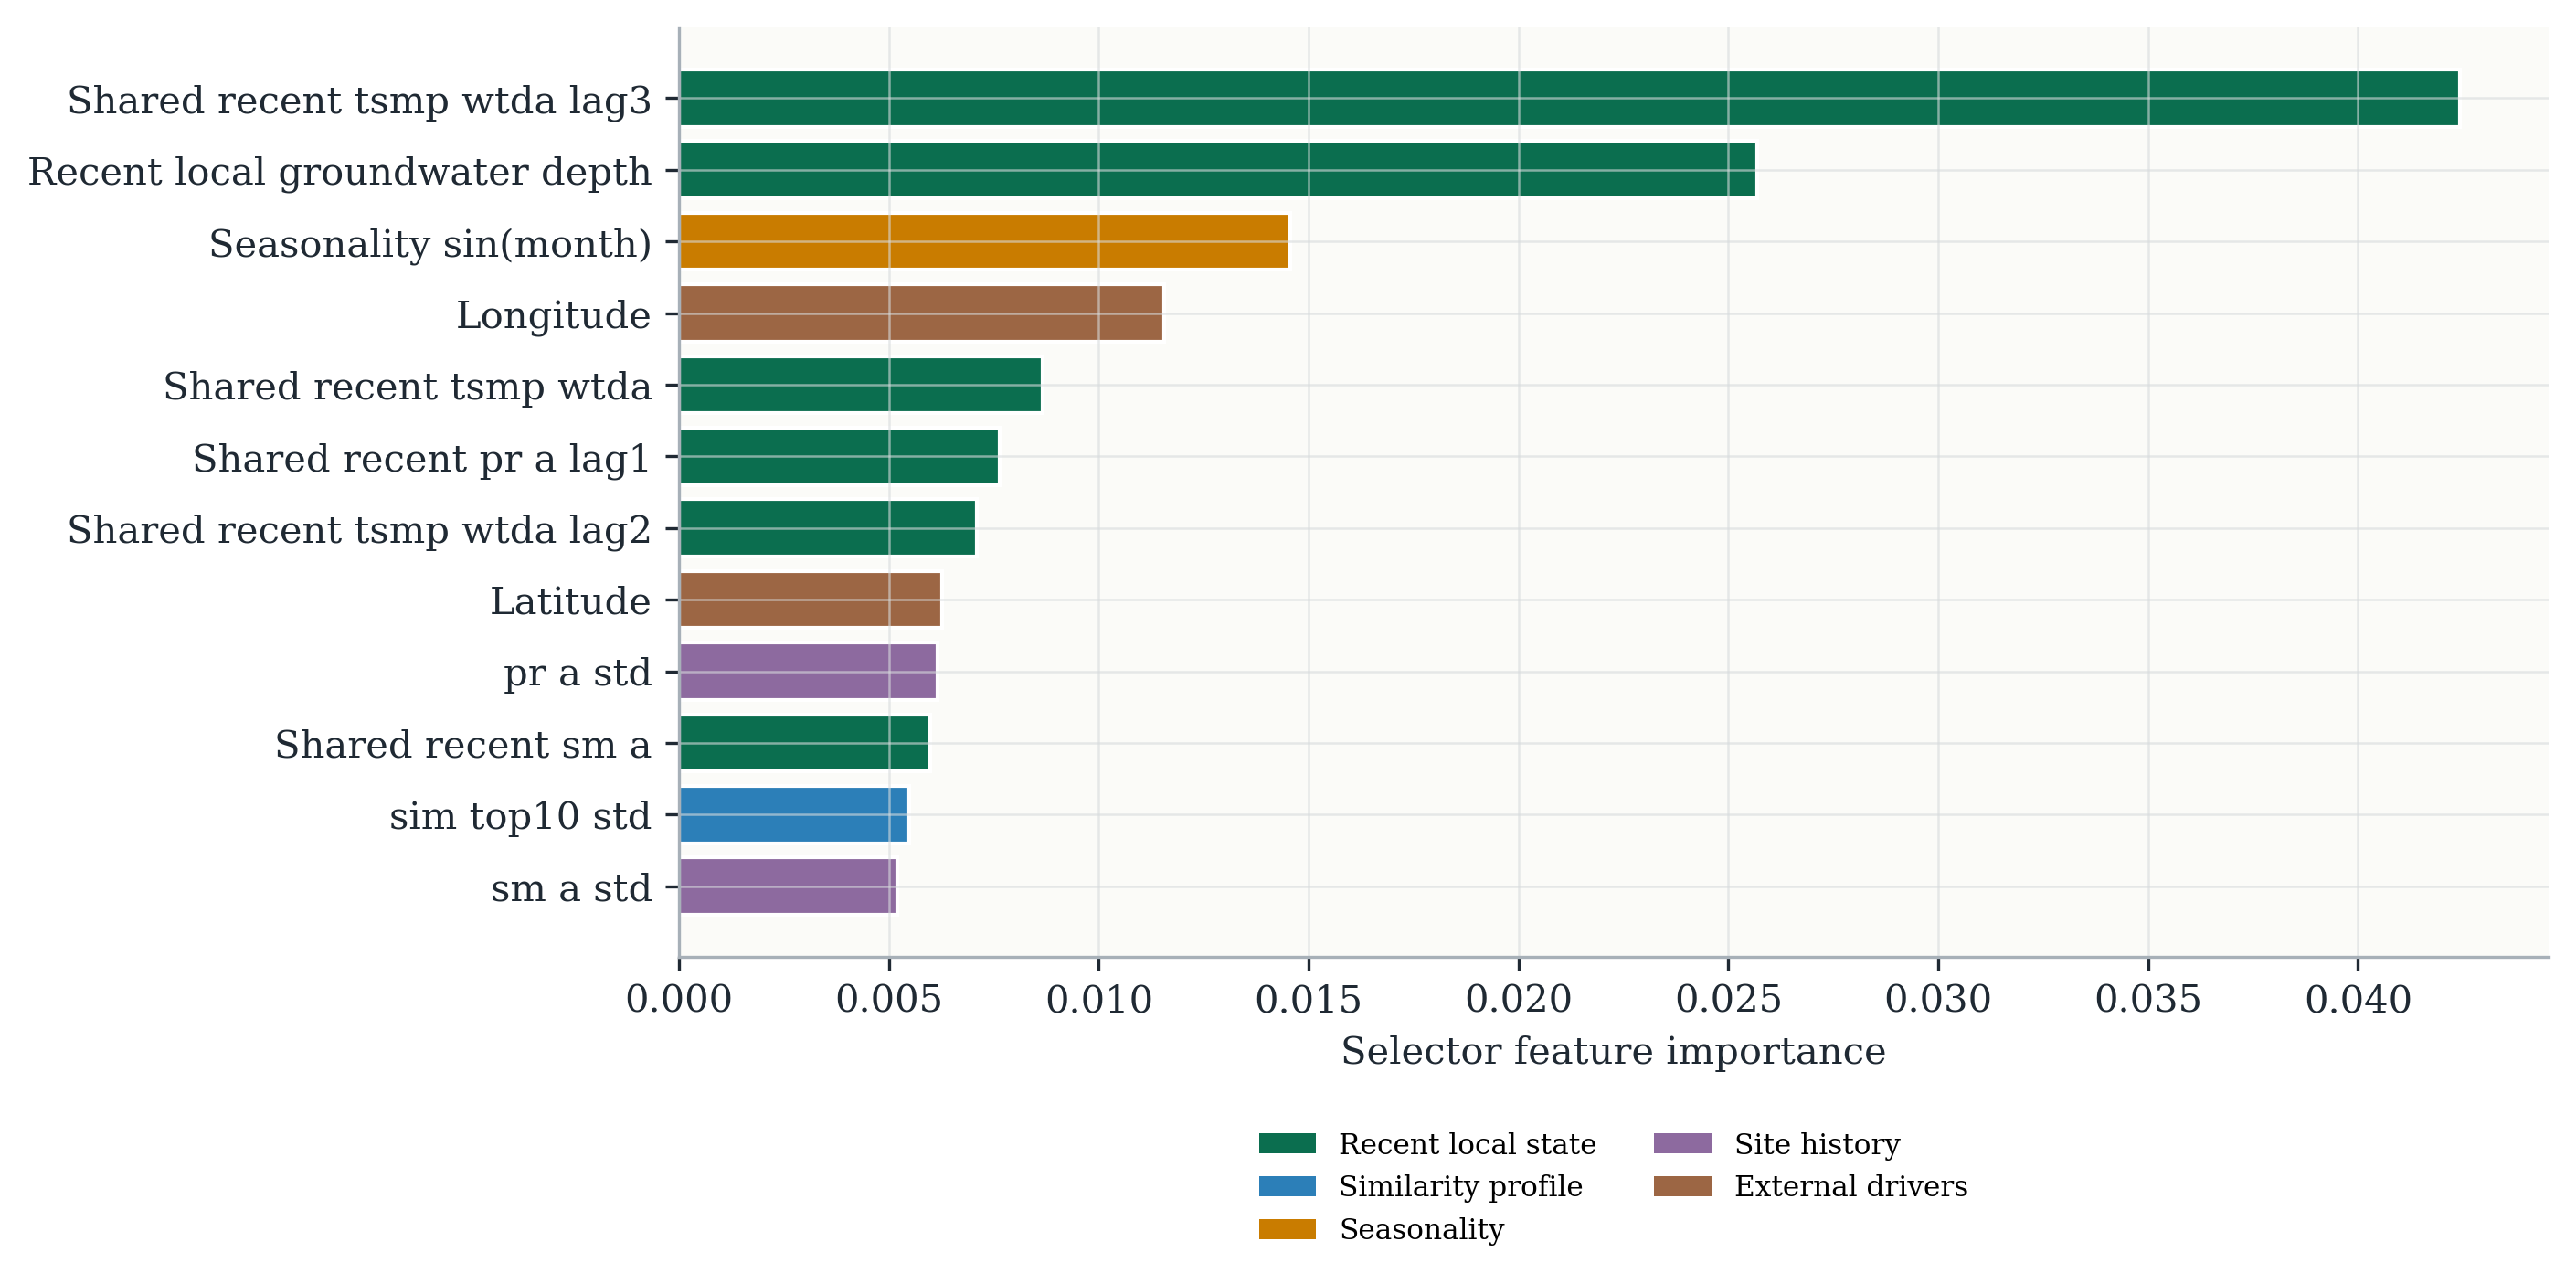

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_selector_feature_importance.png


In [13]:
apply_thesis_style()
selector_importance = read_csv(methodology_table_path("selector_feature_importance.csv")).copy()
top_features = selector_importance.nlargest(12, "importance").copy().sort_values("importance", ascending=True)
top_features["feature_label"] = top_features["feature"].map(_humanize_feature)
top_features["feature_group"] = top_features["feature"].map(_feature_group)
top_features["color"] = top_features["feature_group"].map(FEATURE_GROUP_COLORS)

fig, ax = plt.subplots(figsize=(8.8, 5.3))
ax.barh(
    top_features["feature_label"],
    top_features["importance"],
    color=top_features["color"],
    edgecolor="white",
    linewidth=1.0,
)
ax.set_xlabel("Selector feature importance")
feature_handles = [
    Patch(facecolor=color, edgecolor="none", label=group)
    for group, color in FEATURE_GROUP_COLORS.items()
    if group in set(top_features["feature_group"])
]
ax.legend(handles=feature_handles, frameon=False, fontsize=7.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.subplots_adjust(bottom=0.24)
selector_feature_path = save_and_display(fig, "results_selector_feature_importance.png", width=980)


Feature-importance results indicate that recent local groundwater state, seasonal structure, similarity diagnostics, and site-history summaries are among the most influential inputs. This pattern is consistent with a selector that combines target-specific context with source-target compatibility rather than relying on any one signal.

/Users/izhan/opt/anaconda3/envs/thsis/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


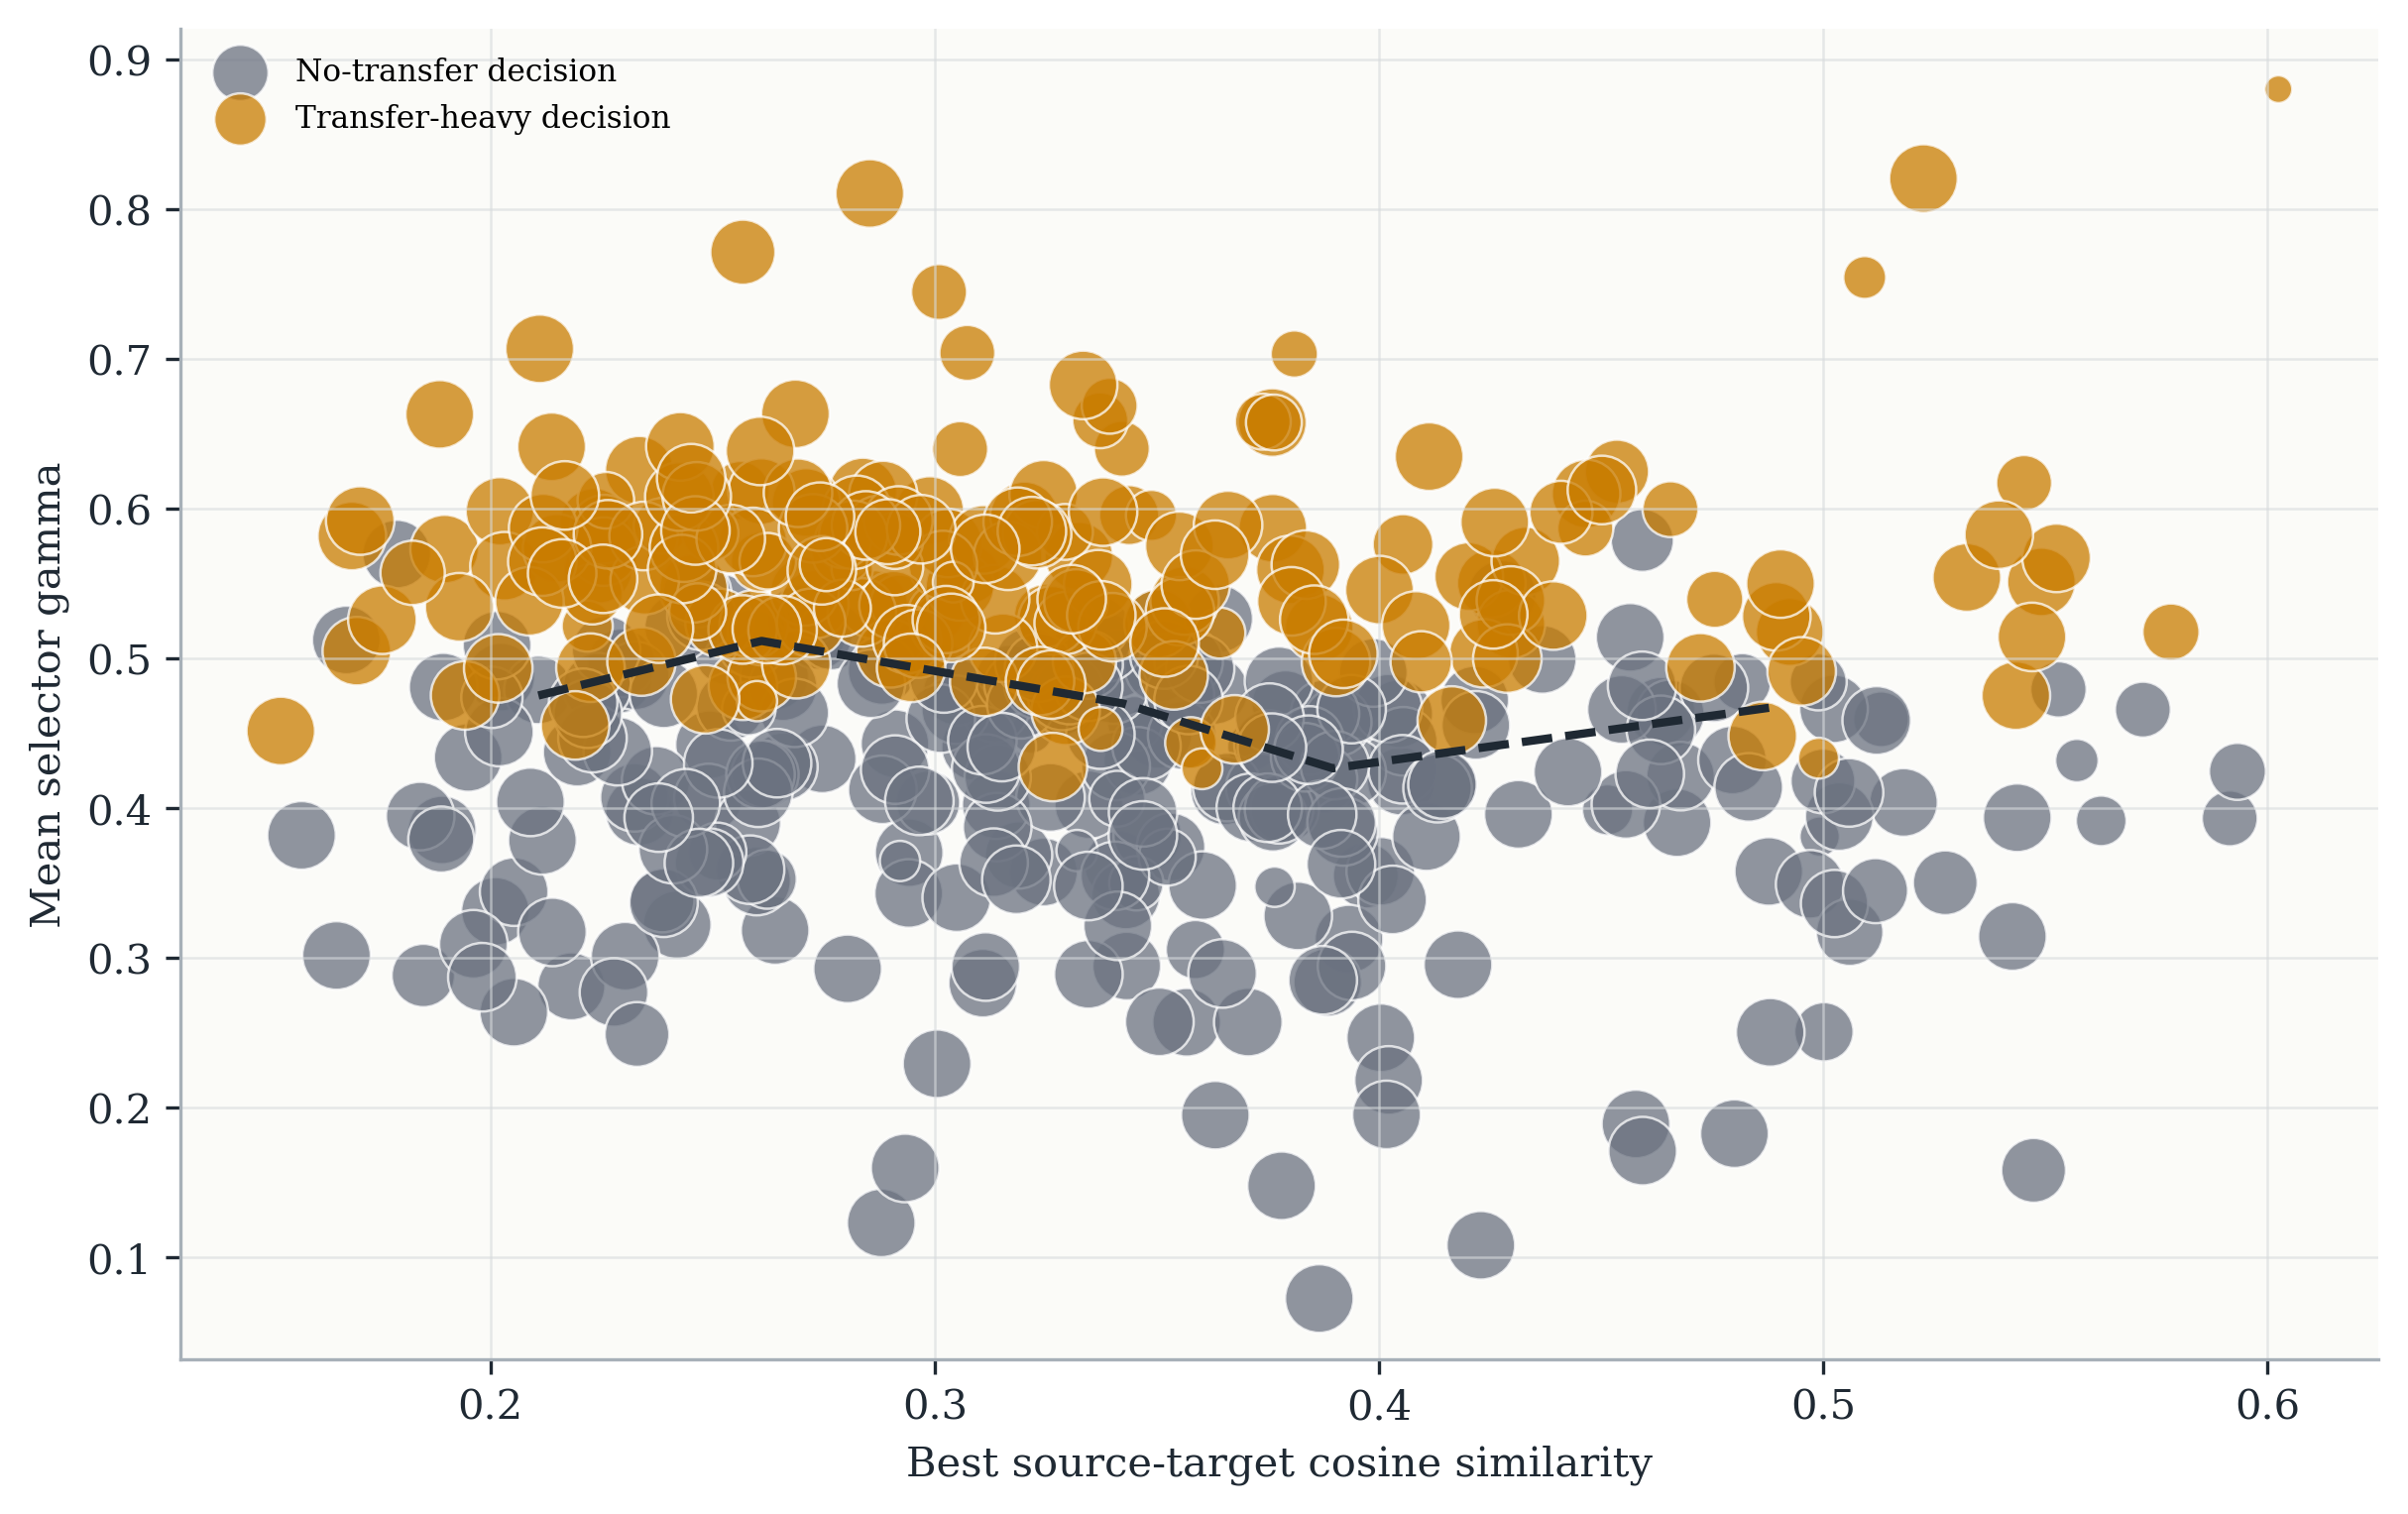

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_selector_decision_pattern.png


In [14]:
apply_thesis_style()
selector_by_site = read_csv(methodology_table_path("selector_by_site.csv")).copy()
selector_by_site["decision_group"] = selector_by_site["selected_parent"].fillna("Deep Context LSTM (No TL)").map(
    {
        "Deep Context LSTM (Always TL)": "Transfer-heavy decision",
        "Deep Context LSTM (No TL)": "No-transfer decision",
        "Random Forest": "Fallback baseline",
    }
).fillna("Fallback baseline")

decision_colors = {
    "Transfer-heavy decision": "#C97C00",
    "No-transfer decision": "#6B7280",
    "Fallback baseline": "#2C7FB8",
}

fig, ax = plt.subplots(figsize=(8.2, 5.2))
for decision_group, sub in selector_by_site.groupby("decision_group", observed=True):
    ax.scatter(
        sub["cosine_similarity"],
        sub["selector_gamma_mean"],
        s=np.clip(sub["months_used"].fillna(sub["months_used"].median()), 5, 110) * 2.5,
        alpha=0.75,
        color=decision_colors[decision_group],
        edgecolor="white",
        linewidth=0.6,
        label=decision_group,
    )

binned = _binned_mean(selector_by_site, "cosine_similarity", "selector_gamma_mean")
if not binned.empty:
    ax.plot(binned["x_mean"], binned["y_mean"], color="#1F2933", linewidth=2.0, linestyle="--")

ax.set_xlabel("Best source-target cosine similarity")
ax.set_ylabel("Mean selector gamma")
ax.legend(frameon=False, fontsize=7.5, loc="upper left")
fig.tight_layout()
selector_decision_path = save_and_display(fig, "results_selector_decision_pattern.png", width=900)


The decision plot shows that transfer-heavy decisions occur more often when the best source-target similarity is stronger, although the relationship is not deterministic. This is consistent with a selector that uses similarity as one important cue without collapsing into a single hard threshold rule.

## 6. Error Analysis

Error analysis identifies where the strongest model fails, not only which model has the lowest average RMSE. The diagnostics focus on anomaly magnitude, calendar month, site-level failure cases, and whether the selector's decision pattern matches the actual error structure.

In [15]:
error_regime = read_csv(methodology_table_path("error_by_anomaly_regime.csv")).copy()
error_month = read_csv(methodology_table_path("error_by_calendar_month.csv")).copy()
site_diag = read_csv(methodology_table_path("site_error_diagnostics.csv")).copy()
selector_failure = read_csv(methodology_table_path("selector_failure_typology.csv")).copy()
driver_corr = read_csv(methodology_table_path("error_driver_correlations.csv")).copy()
worst_sites = read_csv(methodology_table_path("worst_site_error_profile.csv")).copy()

key_error_numbers = pd.DataFrame(
    [
        {
            "diagnostic": "extreme_test_observation_share",
            "value": float(site_diag["extreme_share_abs_gt_1_5"].mul(site_diag["n_test"]).sum() / site_diag["n_test"].sum()),
        },
        {
            "diagnostic": "selector_matches_test_best_parent_share",
            "value": float(site_diag["selection_matches_test_best_parent"].mean()),
        },
        {
            "diagnostic": "median_selector_penalty_vs_test_best_parent",
            "value": float(site_diag["rmse_gap_vs_test_best_parent"].median()),
        },
        {
            "diagnostic": "max_site_hard_abs_error",
            "value": float(site_diag["max_abs_error"].max()),
        },
    ]
)
display(key_error_numbers.round(3))
display(driver_corr.head(6).round(3))
display(worst_sites[["site_id", "n_test", "site_hard_rmse", "test_target_std", "max_abs_target", "max_abs_error", "selected_parent", "test_best_parent", "selector_failure_type"]].round(3))


,diagnostic,value
0,extreme_test_observation_share,0.201
1,selector_matches_test_best_parent_share,0.562
2,median_selector_penalty_vs_test_best_parent,0.000
3,max_site_hard_abs_error,68.838


,driver,n_sites,spearman_rho_with_site_hard_rmse,p_value,abs_spearman_rho
0,test_target_std,496,0.827,0.0,0.827
1,max_abs_target,496,0.685,0.0,0.685
2,extreme_share_abs_gt_1_5,496,0.553,0.0,0.553
3,mean_abs_target,496,0.482,0.0,0.482
4,sim_top3_mean,494,-0.366,0.0,0.366
5,cosine_similarity,494,-0.361,0.0,0.361


,site_id,n_test,site_hard_rmse,test_target_std,max_abs_target,max_abs_error,selected_parent,test_best_parent,selector_failure_type
0,53523,37.0,28.791,7.782,41.751,39.973,Deep Context LSTM (No TL),Deep Context LSTM (No TL),selected_test_best_parent
1,13392,37.0,22.048,19.942,69.290,68.838,Deep Context LSTM (Always TL),Deep Context LSTM (Always TL),selected_test_best_parent
2,30516,3.0,7.948,3.508,11.414,10.132,Deep Context LSTM (Always TL),Deep Context LSTM (No TL),selected_test_worse_parent
3,33342,32.0,7.007,2.146,12.459,9.498,Deep Context LSTM (No TL),Deep Context LSTM (Always TL),selected_test_worse_parent
4,29245,20.0,6.085,3.596,15.008,13.266,Deep Context LSTM (Always TL),Deep Context LSTM (No TL),selected_test_worse_parent
5,31675,17.0,4.942,4.563,20.342,19.556,Deep Context LSTM (No TL),Deep Context LSTM (No TL),selected_test_best_parent
6,37757,31.0,4.648,4.504,19.579,17.562,Deep Context LSTM (No TL),Deep Context LSTM (Always TL),selected_test_worse_parent
7,32424,37.0,4.438,2.129,11.535,7.934,Deep Context LSTM (Always TL),Deep Context LSTM (Always TL),selected_test_best_parent
8,88075,37.0,3.632,2.762,15.292,13.349,Deep Context LSTM (Always TL),Deep Context LSTM (Always TL),selected_test_best_parent
9,118260,24.0,3.484,2.870,10.800,10.430,Deep Context LSTM (No TL),Deep Context LSTM (No TL),selected_test_best_parent


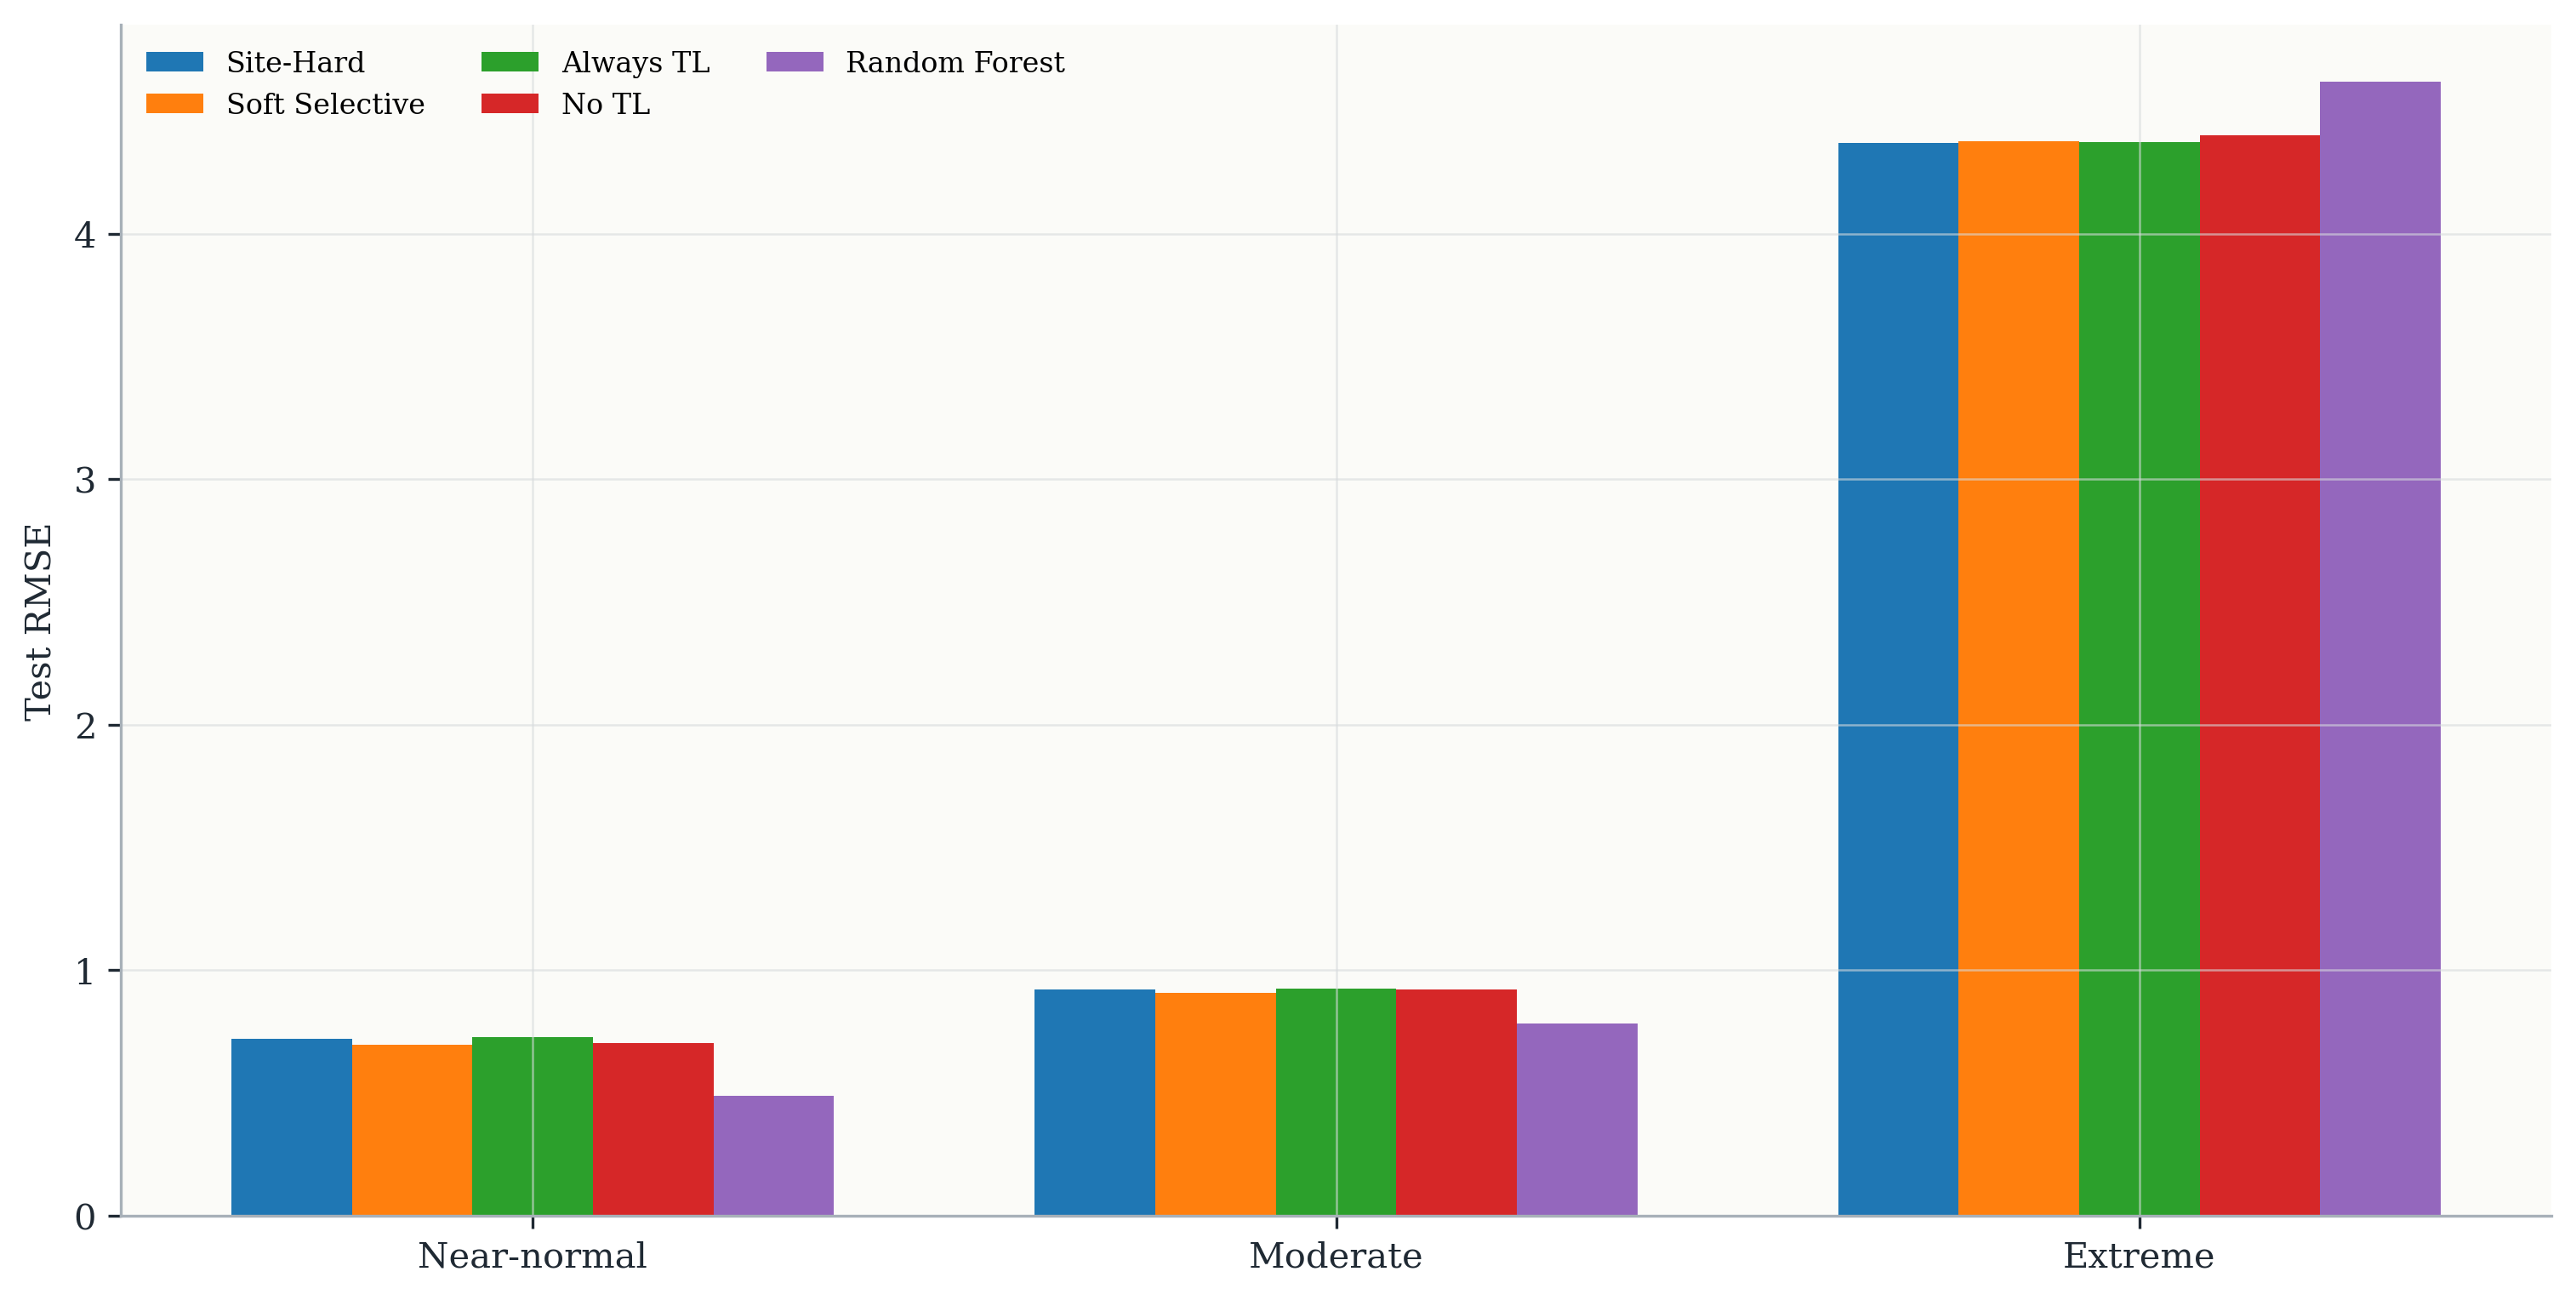

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_error_by_anomaly_regime.png


In [16]:
apply_thesis_style()
focus_models = [
    "Site-Hard Expert Selector",
    "Context-Aware Selective Learning",
    "Deep Context LSTM (Always TL)",
    "Deep Context LSTM (No TL)",
    "Random Forest",
]
label_map = {
    "Site-Hard Expert Selector": "Site-Hard",
    "Context-Aware Selective Learning": "Soft Selective",
    "Deep Context LSTM (Always TL)": "Always TL",
    "Deep Context LSTM (No TL)": "No TL",
    "Random Forest": "Random Forest",
}
regime_order = ["near-normal |y| <= 0.5", "moderate 0.5 < |y| <= 1.5", "extreme |y| > 1.5"]
plot_df = error_regime.query("model_family in @focus_models").copy()
plot_df["model_label"] = plot_df["model_family"].map(label_map)
plot_df["target_abs_regime"] = pd.Categorical(plot_df["target_abs_regime"], categories=regime_order, ordered=True)
plot_df = plot_df.sort_values(["target_abs_regime", "model_label"])

fig, ax = plt.subplots(figsize=(10.2, 5.2))
x = np.arange(len(regime_order))
width = 0.15
for idx, model in enumerate([label_map[m] for m in focus_models]):
    vals = []
    frame = plot_df[plot_df["model_label"].eq(model)].set_index("target_abs_regime")
    for regime in regime_order:
        vals.append(float(frame.loc[regime, "rmse"]) if regime in frame.index else np.nan)
    offset = (idx - 2) * width
    ax.bar(x + offset, vals, width=width, label=model)
ax.set_xticks(x, ["Near-normal", "Moderate", "Extreme"])
ax.set_ylabel("Test RMSE")
ax.legend(ncol=3, frameon=False, fontsize=8)
fig.tight_layout()
error_regime_path = save_and_display(fig, "results_error_by_anomaly_regime.png", width=920)


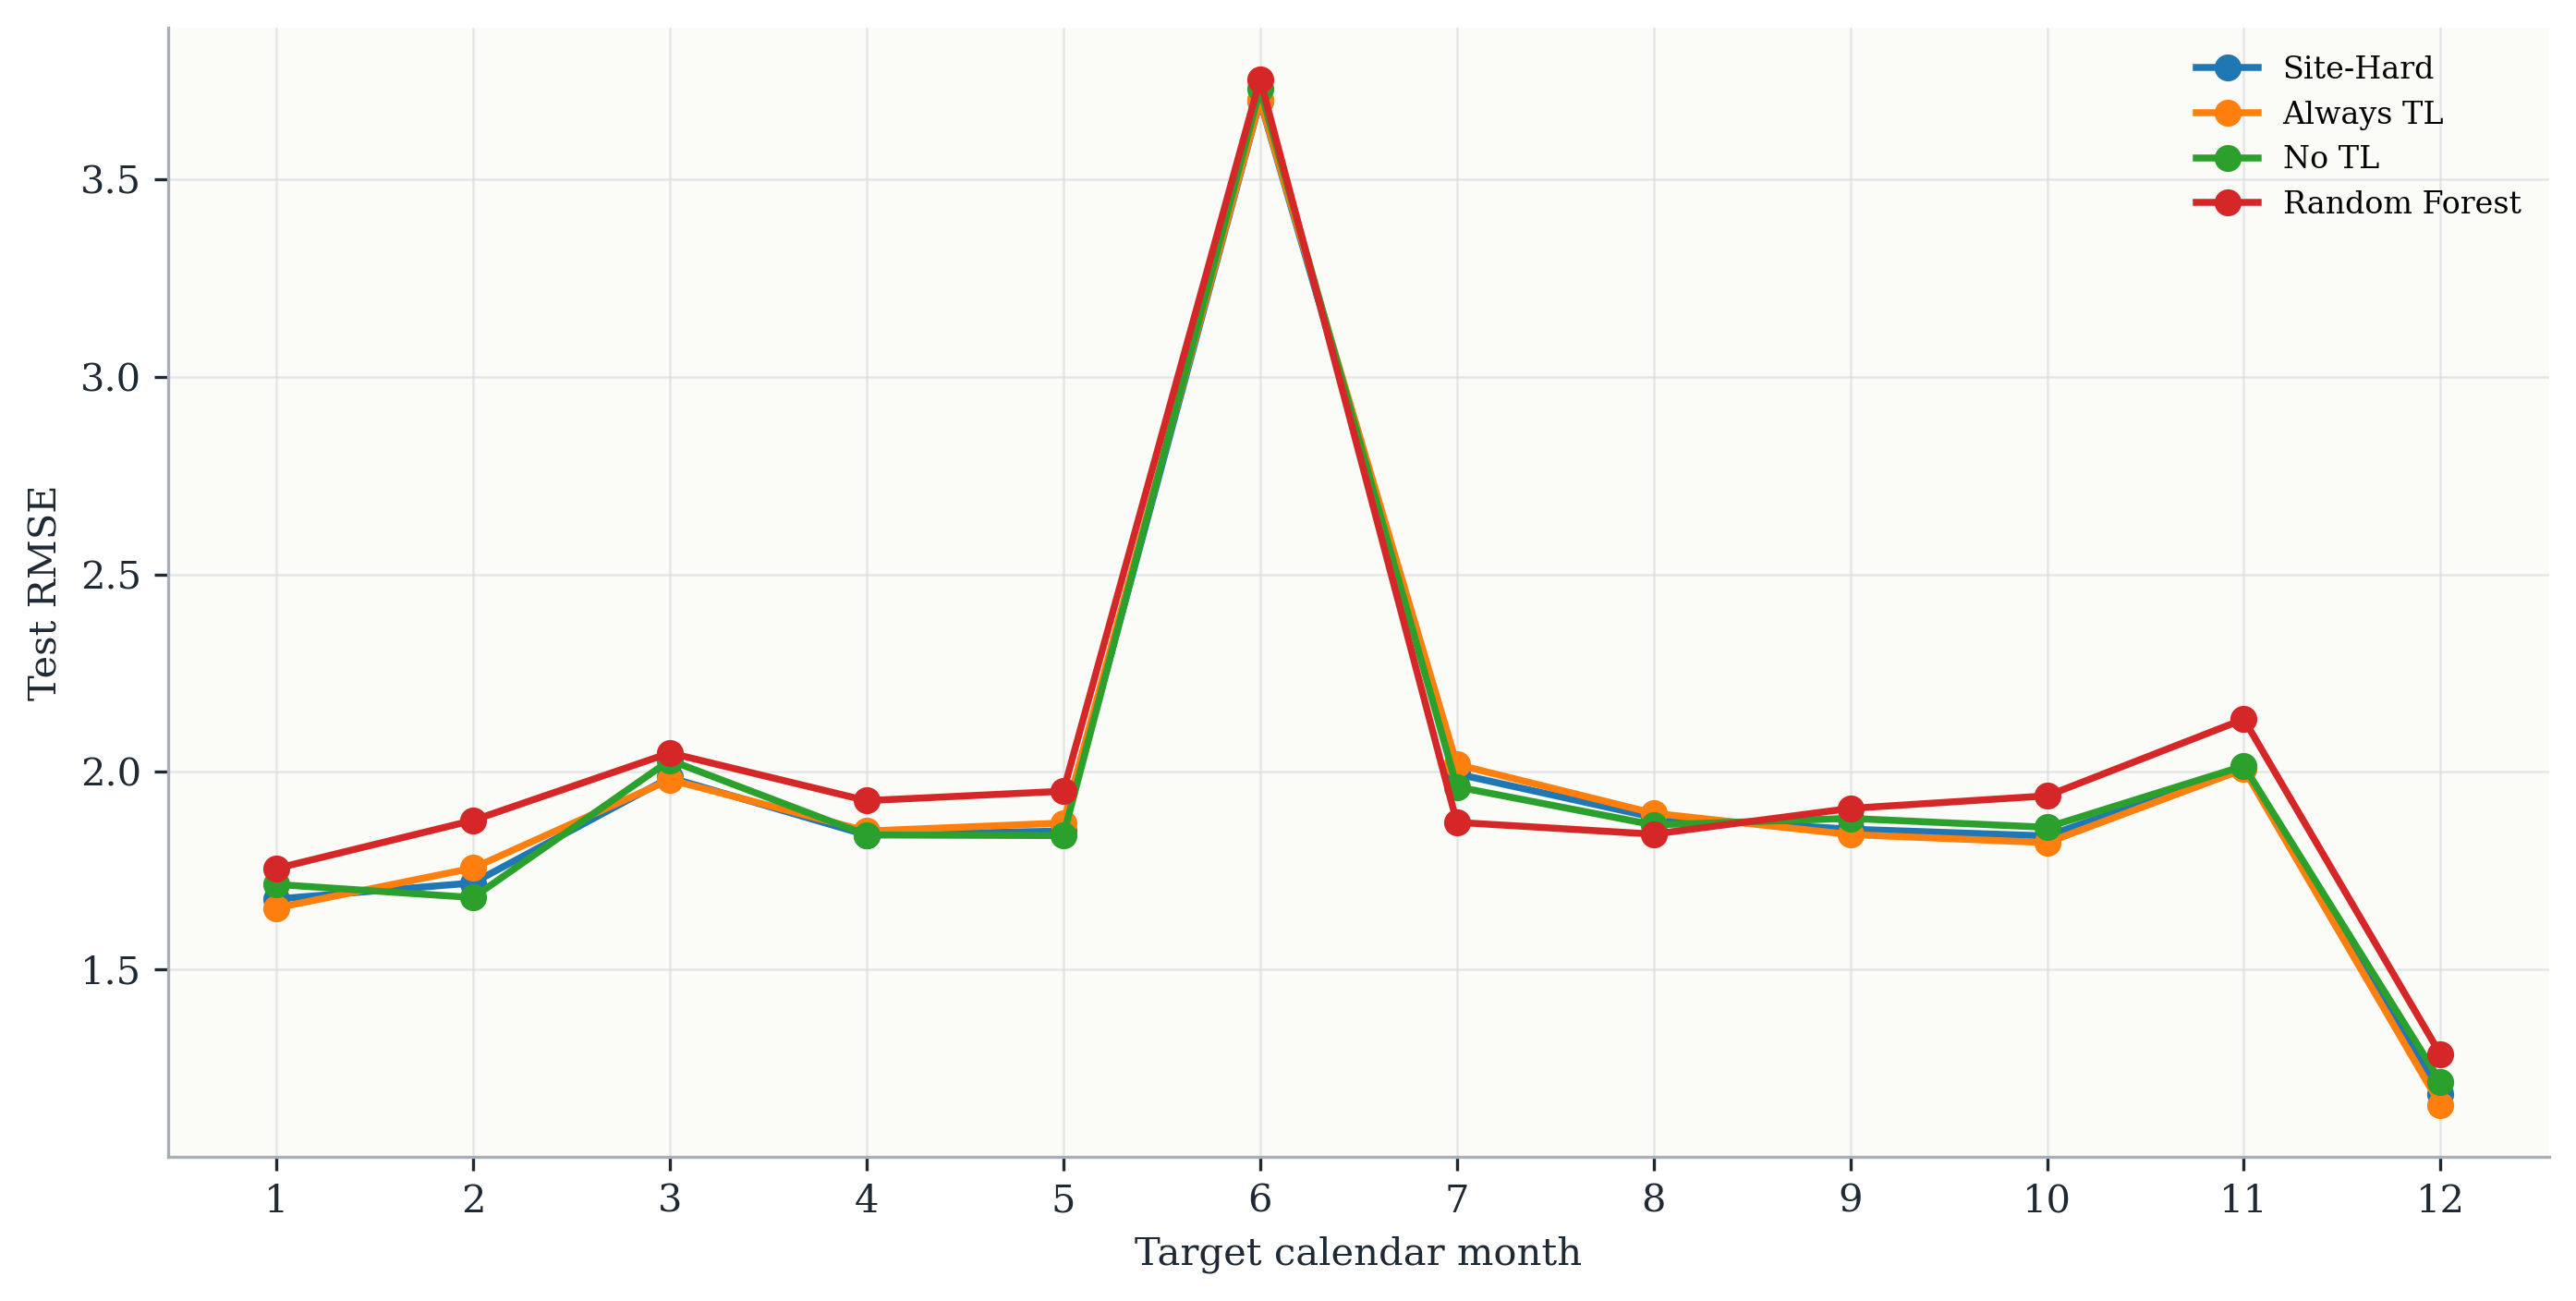

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_error_by_calendar_month.png


In [17]:
apply_thesis_style()
month_focus = ["Site-Hard Expert Selector", "Deep Context LSTM (Always TL)", "Deep Context LSTM (No TL)", "Random Forest"]
month_df = error_month.query("model_family in @month_focus").copy()
fig, ax = plt.subplots(figsize=(9.4, 4.8))
for model in month_focus:
    frame = month_df[month_df["model_family"].eq(model)].sort_values("target_month_of_year")
    ax.plot(frame["target_month_of_year"], frame["rmse"], marker="o", linewidth=1.8, label=label_map.get(model, model))
ax.set_xticks(range(1, 13))
ax.set_xlabel("Target calendar month")
ax.set_ylabel("Test RMSE")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
monthly_error_path = save_and_display(fig, "results_error_by_calendar_month.png", width=900)


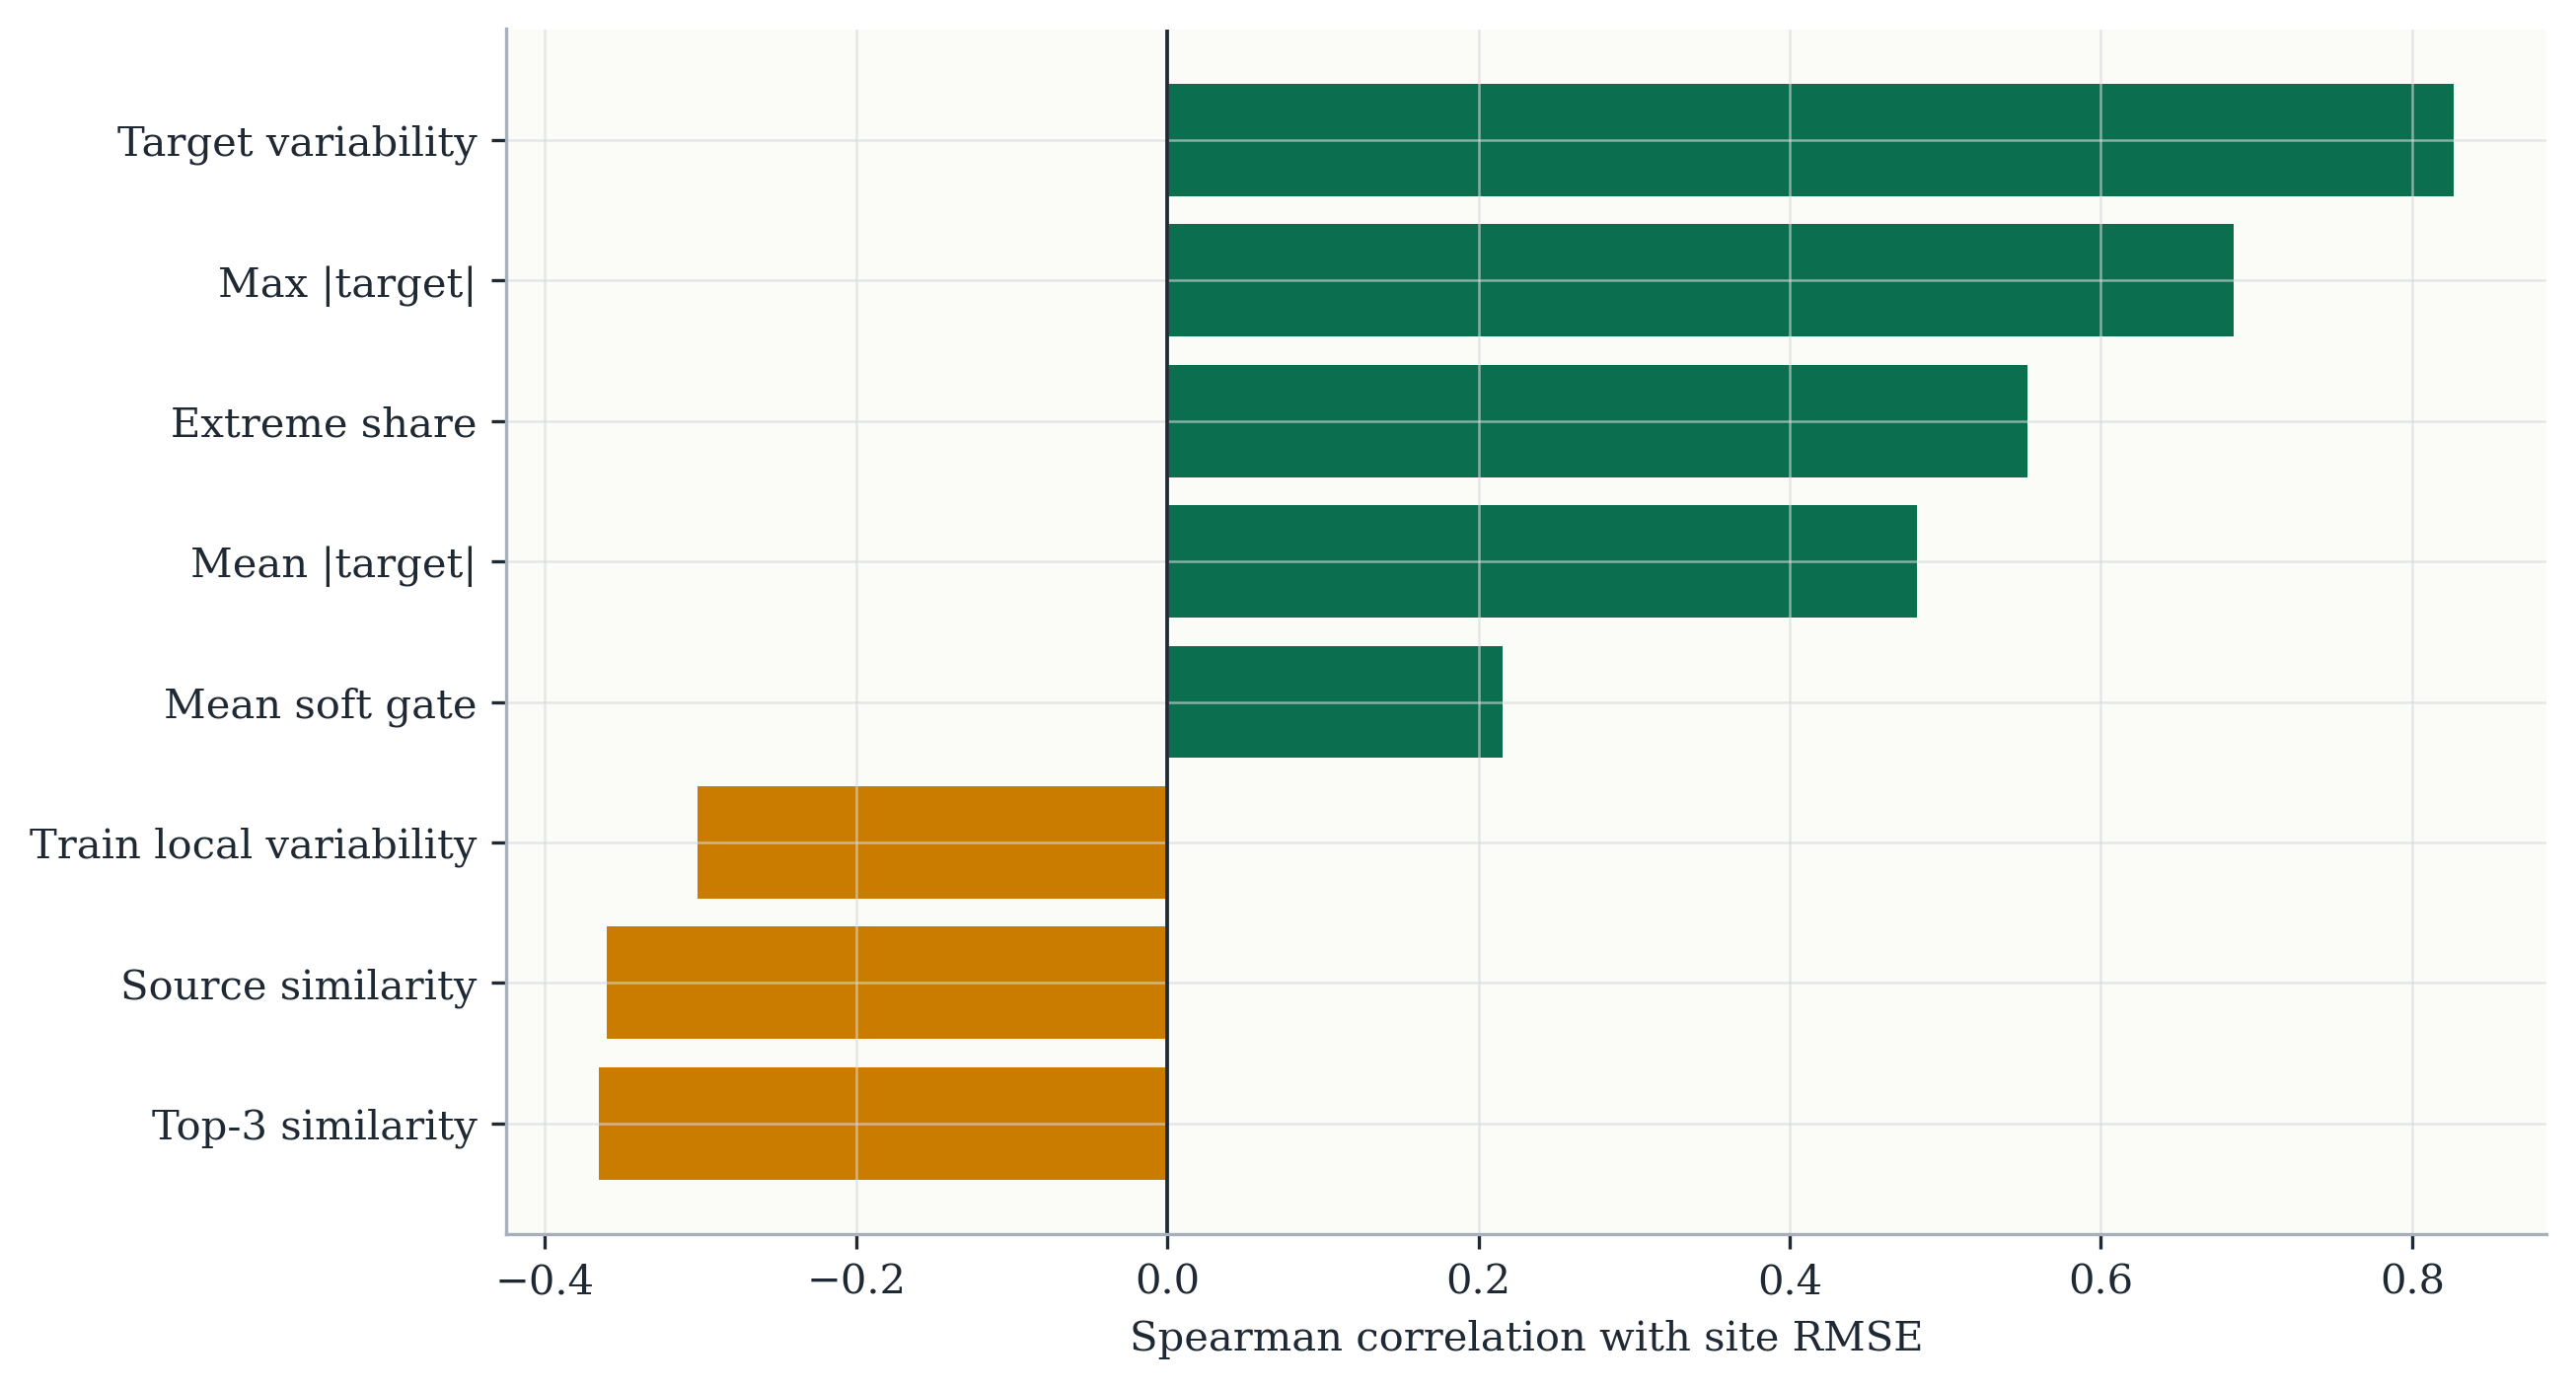

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_error_driver_correlations.png


In [18]:
apply_thesis_style()
pretty_driver = {
    "test_target_std": "Target variability",
    "max_abs_target": "Max |target|",
    "mean_abs_target": "Mean |target|",
    "extreme_share_abs_gt_1_5": "Extreme share",
    "cosine_similarity": "Source similarity",
    "wtda_std": "Train local variability",
    "sim_top3_mean": "Top-3 similarity",
    "max_observations": "Historical observations",
    "selector_gamma_mean": "Mean soft gate",
    "train_rows": "Train rows",
    "months_used": "Matched months",
}
plot_corr = driver_corr.head(8).copy().sort_values("spearman_rho_with_site_hard_rmse")
plot_corr["label"] = plot_corr["driver"].map(pretty_driver).fillna(plot_corr["driver"])
colors = ["#0B6E4F" if value >= 0 else "#C97C00" for value in plot_corr["spearman_rho_with_site_hard_rmse"]]
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.barh(plot_corr["label"], plot_corr["spearman_rho_with_site_hard_rmse"], color=colors)
ax.axvline(0, color="#1F2933", linewidth=0.9)
ax.set_xlabel("Spearman correlation with site RMSE")
fig.tight_layout()
driver_path = save_and_display(fig, "results_error_driver_correlations.png", width=880)


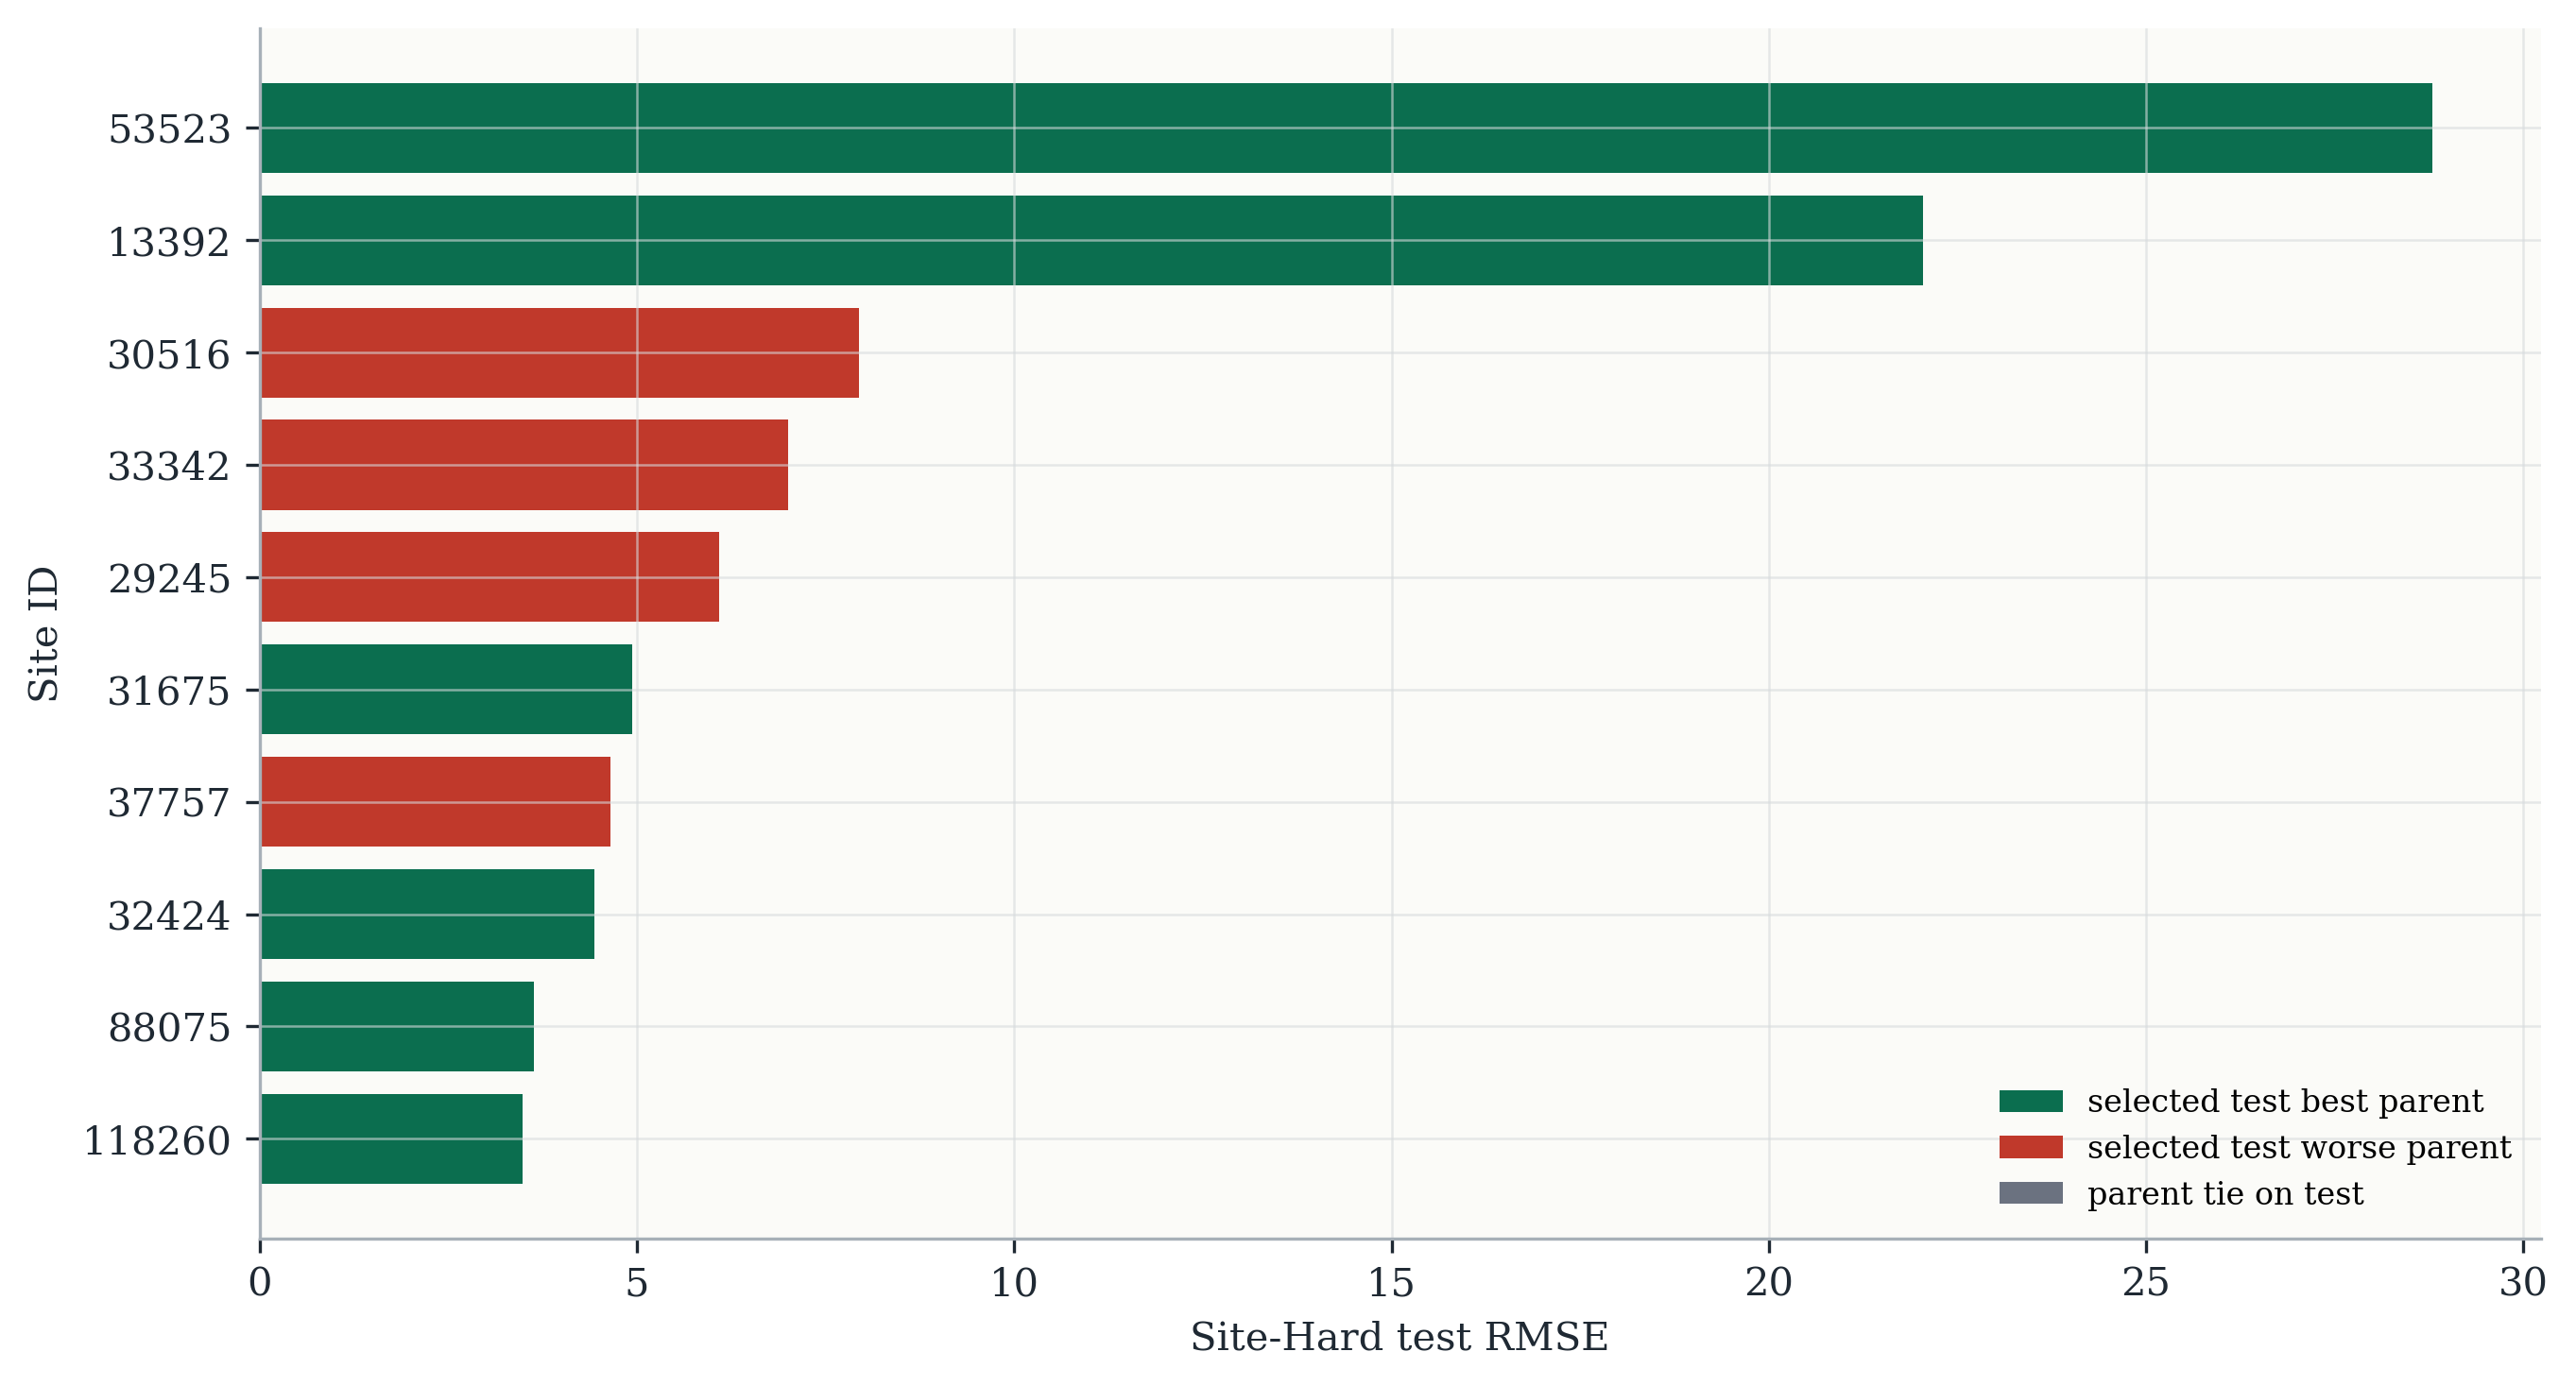

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_worst_site_error_profile.png


In [19]:
apply_thesis_style()
worst_plot = worst_sites.head(10).copy().sort_values("site_hard_rmse")
color_map = {
    "selected_test_best_parent": "#0B6E4F",
    "selected_test_worse_parent": "#C0392B",
    "parent_tie_on_test": "#6B7280",
}
colors = [color_map.get(value, "#6B7280") for value in worst_plot["selector_failure_type"]]
fig, ax = plt.subplots(figsize=(9.2, 5.0))
ax.barh(worst_plot["site_id"].astype(str), worst_plot["site_hard_rmse"], color=colors)
ax.set_xlabel("Site-Hard test RMSE")
ax.set_ylabel("Site ID")
legend_items = [Patch(facecolor=color, label=label.replace("_", " ")) for label, color in color_map.items()]
ax.legend(handles=legend_items, frameon=False, fontsize=8, loc="lower right")
fig.tight_layout()
worst_path = save_and_display(fig, "results_worst_site_error_profile.png", width=900)


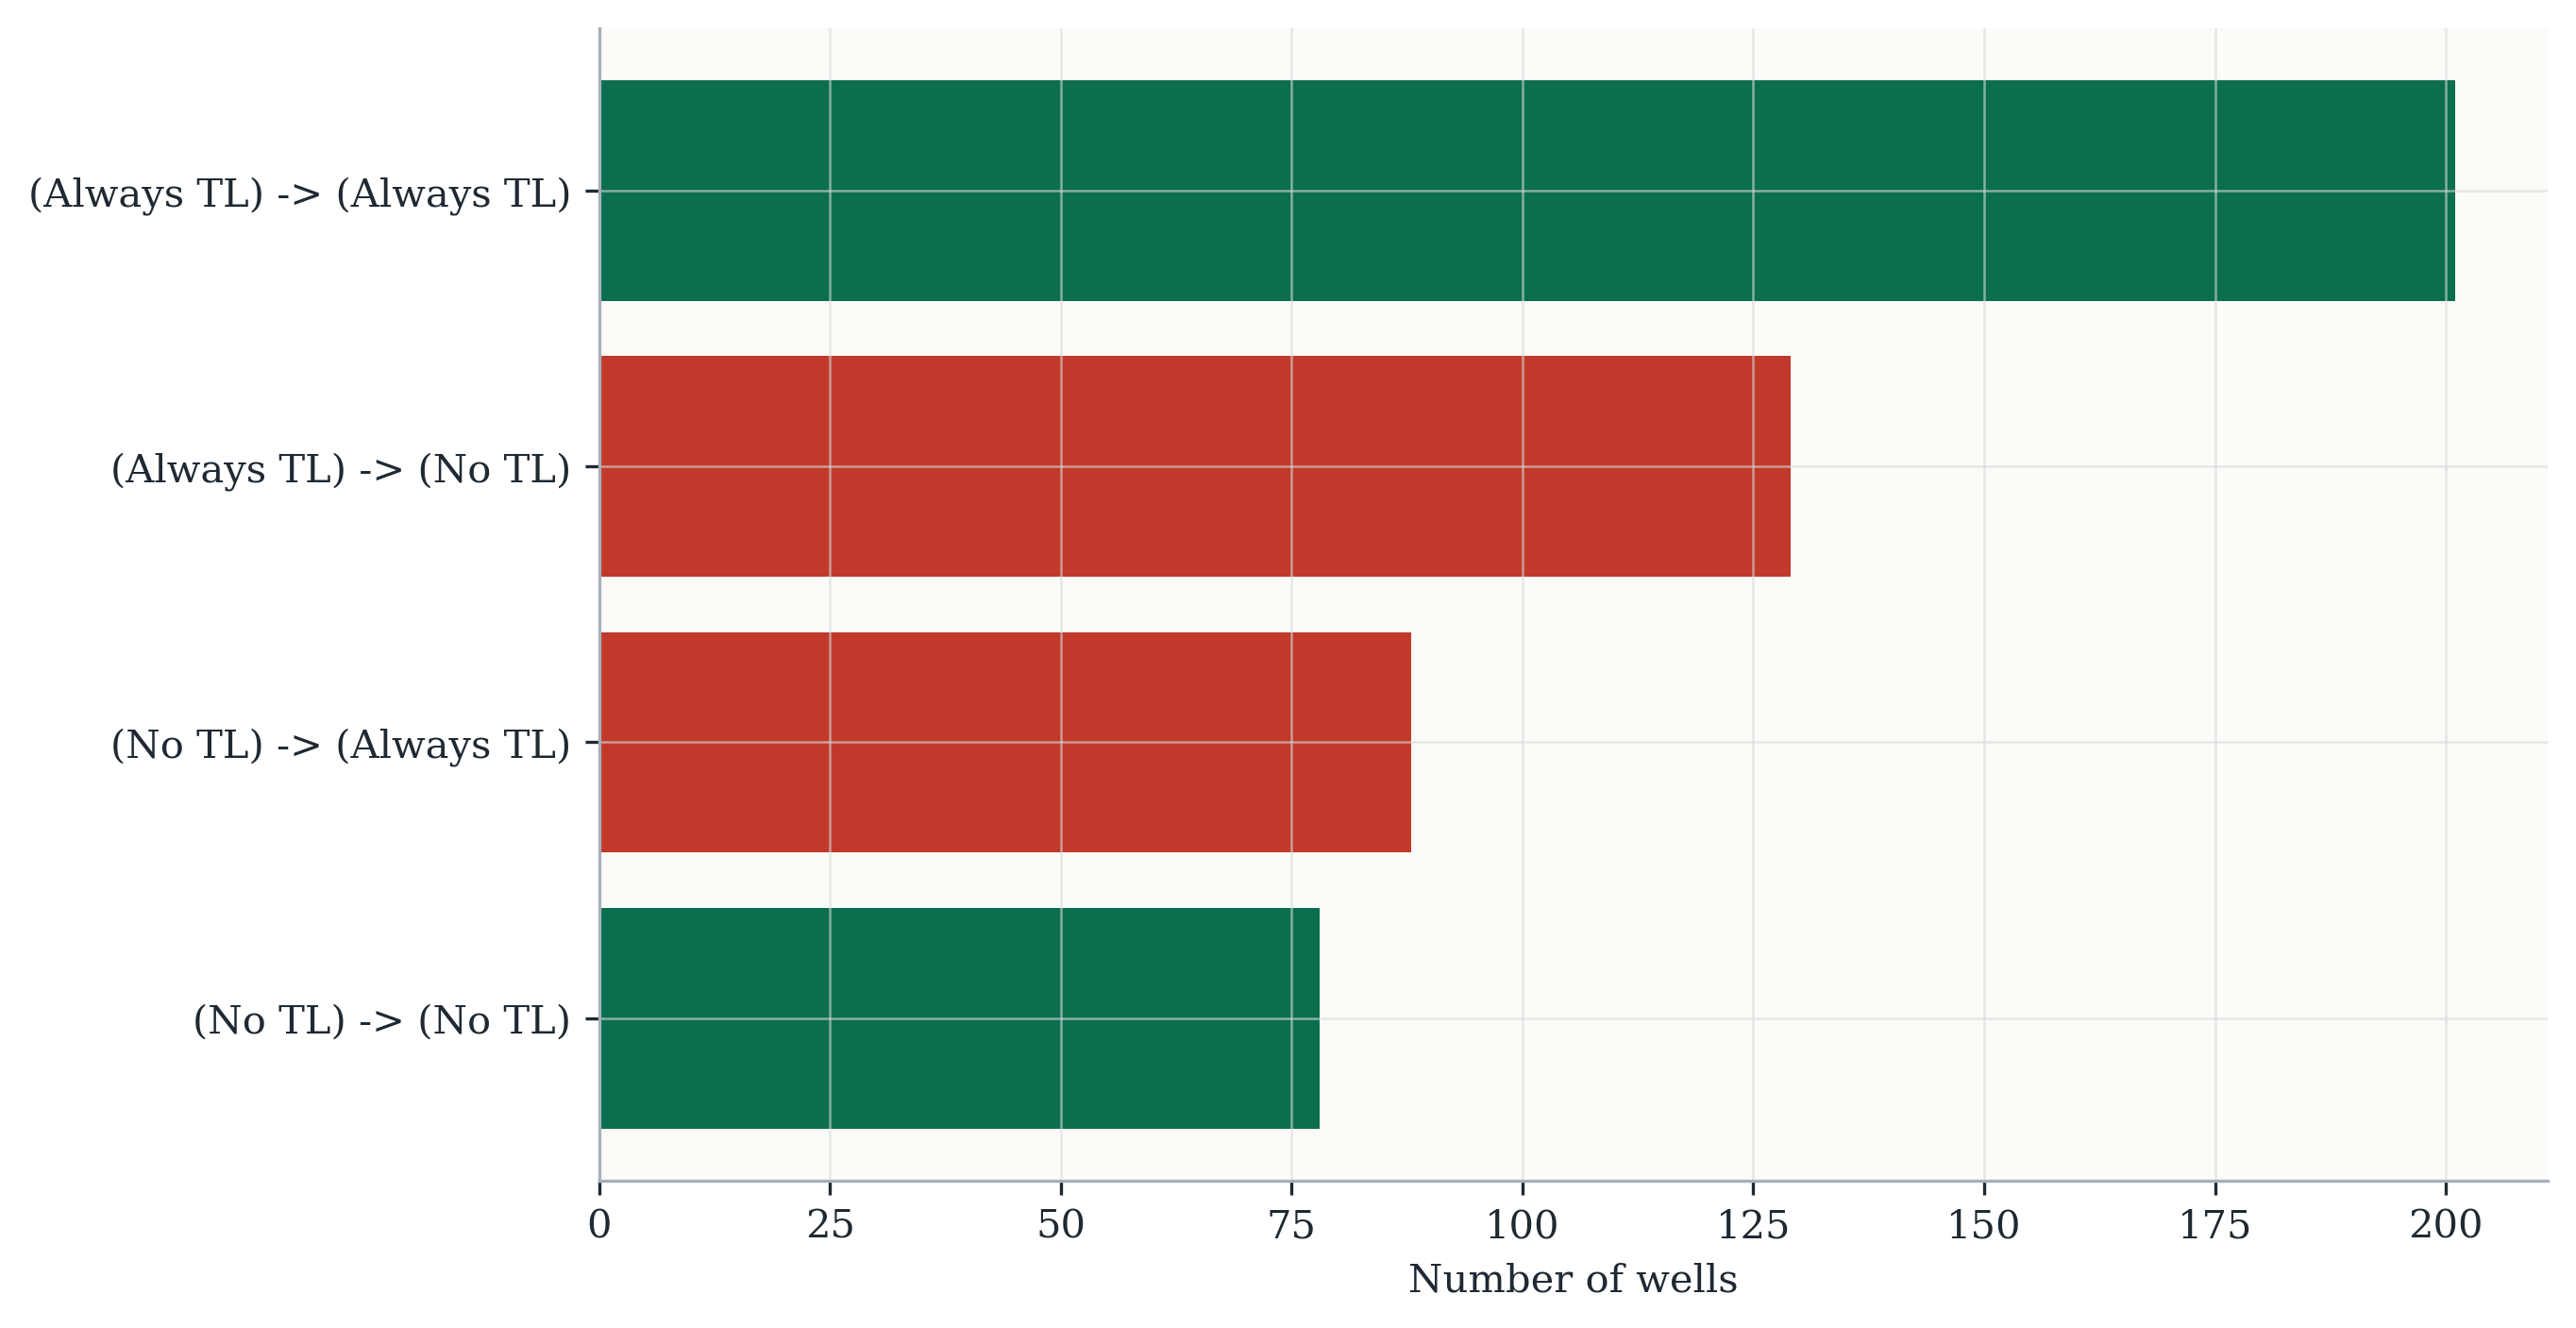

Saved: /Users/izhan/Desktop/groundwater/stephanie_thesis_groundwater/Data/processed/results/figures/results_selector_failure_typology.png


In [20]:
apply_thesis_style()
failure_plot = selector_failure.copy()
failure_plot["route"] = (
    failure_plot["selected_parent"].str.replace("Deep Context LSTM ", "", regex=False)
    + " -> "
    + failure_plot["test_best_parent"].str.replace("Deep Context LSTM ", "", regex=False)
)
failure_plot = failure_plot.sort_values("sites", ascending=True)
fig, ax = plt.subplots(figsize=(9.2, 4.8))
colors = ["#0B6E4F" if value == "selected_test_best_parent" else "#C0392B" for value in failure_plot["selector_failure_type"]]
ax.barh(failure_plot["route"], failure_plot["sites"], color=colors)
ax.set_xlabel("Number of wells")
ax.set_ylabel("")
fig.tight_layout()
failure_path = save_and_display(fig, "results_selector_failure_typology.png", width=900)


The error analysis shows that the average result is dominated by anomaly magnitude: errors are small for near-normal target months, moderate for mid-range anomalies, and disproportionately large on extreme months. A small number of extreme observations therefore drives the pooled RMSE more than the bulk of routine forecasts, which is consistent with the Random Forest pattern noted above (small per-site errors but large blow-ups on a few hard wells).

## 7. Discussion And Limitations

On the Netherlands target dataset, Context-Aware Selective Learning is the best ranked model under the common chronological split. The pooled gain over the strongest deep baselines is small, but selective transfer beats the earlier LSTM reference models by a clearly larger margin, and the per-well outcome distribution shows where the selective contribution sits: it controls the worst-case damage that fixed transfer imposes on the well-level minority. The contribution is therefore better described as transfer-risk control at the well level than as a large jump in aggregate accuracy.

Several limits should be kept in mind. The target panel is the source-compatible subset of all eligible Dutch BRO wells under the 1996-2016 modelling constraints, not every groundwater well in the Netherlands. Source and target are not the same measurement process; the source domain is gridded hydroclimatic anomaly cells. Monthly aggregation makes the learning problem more stable but hides short-term shocks. Selective learning adds modelling complexity and a separate calibration stage. Seed stability, rolling temporal folds, and selector ablation across feature subsets were not rerun for the Netherlands target dataset, so the final robustness claim rests on the site-cluster bootstrap, the paired Wilcoxon tests, the negative-transfer confidence intervals, and the source-filter sensitivity sweep that are reported above.

## Robustness of the Netherlands Result

This section reports robustness analyses that were actually computed on the saved Netherlands outputs. Only analyses with concretely re-computed numbers are shown; seed-stability, rolling-temporal folds, label-budget curves, selector ablation, and cluster bootstrap on the original Amsterdam protocol were **not** re-run for the Netherlands and are explicitly skipped above.

**What is shown:**
- Site-cluster bootstrap (1000 resamples) of pooled-RMSE deltas between Context-Aware Selective Learning and each comparison model.
- Paired site-level Wilcoxon signed-rank tests (Holm-corrected) over the 496 wells.
- Negative-transfer rates with Wilson 95 % and binomial bootstrap confidence intervals.
- Source-filter sensitivity diagnostic — number of source cells surviving each `maxsim` threshold (model retraining per threshold is out of scope and not done).


In [21]:
from pathlib import Path
import pandas as pd

_ROOT = Path.cwd().resolve()
if _ROOT.name.lower() in {'code', 'data'}:
    _ROOT = _ROOT.parent
ROBUSTNESS_DIR = _ROOT / 'Data' / 'processed' / 'methodology' / 'tables' / 'robustness'
TRANSFER_DIR = _ROOT / 'Data' / 'processed' / 'methodology' / 'tables' / 'transfer'

print('Site-cluster bootstrap (1000 resamples, anchor = Context-Aware Selective Learning)')
boot_df = pd.read_csv(ROBUSTNESS_DIR / 'nl_site_bootstrap_significance.csv')
display(boot_df.round(5))

print('Paired site-level Wilcoxon signed-rank tests over 496 wells (Holm-corrected)')
paired_df = pd.read_csv(ROBUSTNESS_DIR / 'nl_paired_site_tests.csv')
display(paired_df.round(6))

print('Negative-transfer confidence intervals')
ci_df = pd.read_csv(TRANSFER_DIR / 'nl_negative_transfer_ci.csv')
display(ci_df.round(4))

print('Source-filter sensitivity diagnostic (no model retraining)')
sens_df = pd.read_csv(ROBUSTNESS_DIR / 'nl_source_filter_sensitivity.csv')
display(sens_df)


Site-cluster bootstrap (1000 resamples, anchor = Context-Aware Selective Learning)


,comparison,mean_delta_rmse,ci_low_2.5pct,ci_high_97.5pct,prob_delta_lt_0_selective_better,ci_excludes_zero_in_favor_of_selective,n_bootstrap
0,Context-Aware Selective Learning − Site-Hard E...,-0.00430,-0.00840,-0.00193,1.000,True,1000
1,Context-Aware Selective Learning − Deep Contex...,-0.01450,-0.02176,-0.00890,1.000,True,1000
2,Context-Aware Selective Learning − Deep Contex...,-0.00604,-0.01031,-0.00116,0.993,True,1000
3,Context-Aware Selective Learning − Random Forest,-0.05485,-0.16416,0.03206,0.735,False,1000
4,Context-Aware Selective Learning − Baseline LS...,-0.23143,-0.33076,-0.13671,1.000,True,1000
5,Context-Aware Selective Learning − Baseline LS...,-0.25263,-0.36095,-0.14465,1.000,True,1000


Paired site-level Wilcoxon signed-rank tests over 496 wells (Holm-corrected)


,comparison,n_sites,median_per_site_rmse_diff,mean_per_site_rmse_diff,n_selective_better,n_selective_worse,n_tie,wilcoxon_statistic,p_value_two_sided,test,p_holm,significant_holm_0.05
0,Context-Aware Selective Learning vs Site-Hard ...,496,-0.00952,-0.00969,331,165,0,38646.0,0.000000,Wilcoxon signed-rank,0.000000,True
1,Context-Aware Selective Learning vs Deep Conte...,496,-0.02434,-0.02125,369,127,0,26184.0,0.000000,Wilcoxon signed-rank,0.000000,True
2,Context-Aware Selective Learning vs Deep Conte...,496,-0.00945,-0.01071,324,172,0,39001.0,0.000000,Wilcoxon signed-rank,0.000000,True
3,Context-Aware Selective Learning vs Random Forest,496,0.06990,0.05099,163,333,0,33581.0,0.000000,Wilcoxon signed-rank,0.000000,True
4,Context-Aware Selective Learning vs Baseline L...,496,-0.01770,-0.13465,262,234,0,46417.0,0.000002,Wilcoxon signed-rank,0.000002,True
5,Context-Aware Selective Learning vs Baseline L...,496,-0.01779,-0.14745,258,238,0,46038.0,0.000001,Wilcoxon signed-rank,0.000002,True


Negative-transfer confidence intervals


,metric,numerator,denominator,rate,wilson_ci_low,wilson_ci_high,method
0,always_tl_help_rate_over_all_sites,289,496,0.5827,0.5388,0.6253,Wilson 95% CI
1,always_tl_harm_rate_over_all_sites,207,496,0.4173,0.3747,0.4612,Wilson 95% CI
2,selective_partial_rescue_rate_on_harmed_sites,205,207,0.9903,0.9655,0.9973,Wilson 95% CI
3,selective_full_rescue_rate_on_harmed_sites,80,207,0.3865,0.3228,0.4543,Wilson 95% CI


Source-filter sensitivity diagnostic (no model retraining)


,source_filter_label,tau,n_source_cells_kept,share_of_source_cells_kept,n_target_wells_with_match,share_target_wells_with_match,val_rmse_selective,cal_rmse_selective,test_rmse_selective,ran_full_model_pipeline,validation_selected_for_main_run
0,no_filter,NaN,512,1.0000,496,1.0000,1.590921,2.056101,2.072163,True,False
1,maxsim0.30,0.30,288,0.5625,299,0.6028,NaN,NaN,NaN,False,False
2,maxsim0.35,0.35,198,0.3867,191,0.3851,NaN,NaN,NaN,False,False
3,maxsim0.40,0.40,133,0.2598,108,0.2177,1.589614,2.058276,2.092474,True,True
4,maxsim0.45,0.45,76,0.1484,67,0.1351,NaN,NaN,NaN,False,False
5,maxsim0.50,0.50,34,0.0664,31,0.0625,1.590279,2.050571,2.064445,True,False
6,maxsim0.55,0.55,12,0.0234,9,0.0181,NaN,NaN,NaN,False,False
7,maxsim0.60,0.60,1,0.0020,1,0.0020,1.590164,2.058144,2.095690,True,False


## Results summary

- Context-Aware Selective Learning is the best model on the Netherlands target dataset (test RMSE `2.0925`).
- The main selected source filter is `maxsim0.40` and keeps `133` of `512` source cells. `maxsim0.60` is kept only as a legacy / sensitivity comparison.
- Fixed transfer harms `41.7%` of wells in the panel.
- Selective learning partially rescues `99.0%` of harmed wells and fully rescues `38.6%`.
- The aggregate RMSE gain over the strongest deep baselines is modest, so the main contribution is not a large accuracy jump.
- The main contribution is well-level negative-transfer risk control under the source-compatible 1996-2016 Netherlands modelling window.